# 01 · Exploratory data analysis

Multi-task learning (**sentiment + topic**) on **NEU-ESC** and **UIT-VSFC**.

Every section ends in a **decision for training**. The numbers are written to `reports/eda_summary.json`, so the trainer reads them instead of hard-coding them, and `reports/eda_findings.md` is generated from the same numbers.

| § | Analysis | Decision it feeds |
|---|---|---|
| 2–3 | Combined table, integrity checks | Trust in the data |
| 4 | Label distribution, imbalance | `TaskLoss(kind=...)`, class weights, majority baseline |
| 5 | Sentiment × topic dependence | Evidence for the MTL premise |
| 6 | Word and subword token lengths | `max_length` per (dataset, model); batch size |
| 7 | Vocabulary, distinctive words | OOV, cross-dataset overlap, naming the NEU-ESC topics |
| 8 | Duplicates, leakage, label conflicts | Cleaning rules, trust in test scores |
| 9 | Split shift, adversarial validation, train-dev slice | Reading bias / variance / data-mismatch gaps |
| 10 | Qualitative samples | Checking label names and noise by reading |
| 11 | `eda_summary.json` + `eda_findings.md` | Contract with the trainer |

Run top to bottom. Only the config cell below is meant to be edited.

## 1. Setup

### 1.1 Config
The only cell to edit. `RUN_TOKENS = False` skips subword tokenizers (no downloads); `TOKEN_SAMPLE` tokenizes a random sample per (dataset, split) for a quick run.

In [1]:
DATA_ROOT = None        # None = auto
OUT_DIR = None          # None = auto
SEED = 42
RUN_TOKENS = True       # §6.2 subword lengths
TOKENIZERS = {          # model name -> model position limit
    'vinai/phobert-base-v2': 256,          # input is word-segmented
    'xlm-roberta-base': 512,
    'bert-base-multilingual-cased': 512,
}
TOKEN_SAMPLE = None     # int -> tokenize a random sample per (dataset, split); None = all
RUN_NEAR_DUP = False    # §8.4
RUN_ADV_VAL = True      # §9.2
TRAIN_DEV_FRAC = 0.05   # §9.3
EXPECTED_ROWS = {
    ('neu-esc', 'train'): 23048, ('neu-esc', 'val'): 3305, ('neu-esc', 'test'): 6613,
    ('uit-vsfc', 'train'): 11426, ('uit-vsfc', 'val'): 1583, ('uit-vsfc', 'test'): 3166,
}
NAMES_CONFIRMED = {'uit-vsfc': True, 'neu-esc': False}

### 1.2 Paths
Finds the project, the data and the output folder, locally or on Kaggle, with no hard-coded paths. Order: config value → environment variable (`DPL_PROJECT_ROOT`, `DPL_DATA_ROOT`, `DPL_OUT_DIR`) → project folders → `/kaggle/...`. Everything this notebook writes goes under `OUT`.

In [2]:
import os, sys, re, json, math, time, random, unicodedata, datetime, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown

sys.dont_write_bytecode = True   # importing utils/ must not write __pycache__ into the project
warnings.filterwarnings('ignore', message='IProgress not found')   # tqdm notice from underthesea, harmless
ON_KAGGLE = os.path.isdir('/kaggle/input')


def _is_project(p):
    return (Path(p) / 'utils' / 'dataloader.py').is_file()


def _is_data(p):
    return (Path(p) / 'neu-esc').is_dir() and (Path(p) / 'uit-vsfc').is_dir()


def _search(roots, test, max_depth):
    """Breadth-first search under each root, up to max_depth levels, for a folder passing `test`."""
    for root in map(Path, roots):
        level = [root] if root.is_dir() else []
        for _ in range(max_depth + 1):
            nxt = []
            for d in level:
                if test(d):
                    return d.resolve()
                try:
                    nxt += sorted(c for c in d.iterdir() if c.is_dir())
                except OSError:
                    pass
            level = nxt
    return None


def resolve_project_root():
    env = os.environ.get('DPL_PROJECT_ROOT')
    if env and _is_project(env):
        return Path(env).resolve()
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents[:3]]:
        if _is_project(p):
            return p
    if ON_KAGGLE:
        found = _search(['/kaggle/working', '/kaggle/input'], _is_project, 4)
        if found:
            return found
    raise FileNotFoundError(
        'Project root not found: no folder containing utils/dataloader.py in $DPL_PROJECT_ROOT, '
        'the current folder or its 3 parents' + (', or under /kaggle/working and /kaggle/input' if ON_KAGGLE else '')
        + '. Set DPL_PROJECT_ROOT.')


def resolve_data_root(project_root):
    for cand in (DATA_ROOT, os.environ.get('DPL_DATA_ROOT')):
        if cand:
            if not _is_data(cand):
                raise FileNotFoundError(f'{cand} does not contain neu-esc/ and uit-vsfc/')
            return Path(cand).resolve()
    if _is_data(project_root / 'datasets'):
        return project_root / 'datasets'
    if ON_KAGGLE:
        found = _search(['/kaggle/input'], _is_data, 4)
        if found:
            return found
    raise FileNotFoundError('Data folder not found (needs neu-esc/ and uit-vsfc/). Set DATA_ROOT or DPL_DATA_ROOT.')


def resolve_out_dir(project_root):
    cand = OUT_DIR or os.environ.get('DPL_OUT_DIR')
    if cand:
        return Path(cand).resolve()
    return Path('/kaggle/working/reports') if ON_KAGGLE else project_root / 'reports'


PROJECT_ROOT = resolve_project_root()
DATA = resolve_data_root(PROJECT_ROOT)
OUT = resolve_out_dir(PROJECT_ROOT)
FIG, TAB, CACHE = OUT / 'figures', OUT / 'tables', OUT / 'cache'
for folder in (FIG, TAB, CACHE):
    folder.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from utils.dataloader import load_dataset, segment_words, UIT_VSFC_LABELS, NEU_ESC_LABELS

random.seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

print(f'ON_KAGGLE    = {ON_KAGGLE}')
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'DATA         = {DATA}')
print(f'OUT          = {OUT}')
print(f'CACHE        = {CACHE}')

ON_KAGGLE    = False
PROJECT_ROOT = C:\Users\ADMIN\Works\DPL_project
DATA         = C:\Users\ADMIN\Works\DPL_project\datasets
OUT          = C:\Users\ADMIN\Works\DPL_project\reports
CACHE        = C:\Users\ADMIN\Works\DPL_project\reports\cache


### 1.3 Helpers and plot style
`SUMMARY` collects every number for the trainer; `warn` records problems in it. Tables are saved as CSV (`utf-8-sig`, so Excel shows Vietnamese correctly) and Markdown (own writer: `tabulate` is not installed). Colors follow the entity: train / val / test are always the same three colors.

In [3]:
SUMMARY = {
    'generated_at': datetime.datetime.now().isoformat(timespec='seconds'),
    'on_kaggle': ON_KAGGLE,
    'seed': SEED,
    'integrity': {}, 'labels': {}, 'task_dependence': {}, 'lengths': {}, 'tokens': {},
    'vocab': {}, 'uit_emoticons': {}, 'leakage': {}, 'label_conflicts': {},
    'shift': {'splits': [], 'adversarial': {}},
    'recommend': {'loss': {}, 'max_length': {}, 'batch_plan': [],
                  'train_dev_idx_file': {}, 'test_leaked_idx_file': {}},
    'warnings': [],
}


def warn(msg):
    SUMMARY['warnings'].append(msg)
    print(f'WARNING: {msg}')


def _md_cell(v):
    if v is None or (np.isscalar(v) and not isinstance(v, str) and pd.isna(v)):
        return ''
    if isinstance(v, (bool, np.bool_)):
        return str(bool(v))
    if isinstance(v, (float, np.floating)):
        v = float(v)
        if v.is_integer() and abs(v) < 1e15:
            return f'{int(v):,}'
        return f'{v:,.2f}' if abs(v) >= 1 else f'{v:.4g}'
    if isinstance(v, (int, np.integer)):
        return f'{int(v):,}'
    return str(v).replace('|', '\\|').replace('\n', ' ')


def df_to_markdown(d):
    cols = [str(c) for c in d.columns]
    lines = ['| ' + ' | '.join(cols) + ' |', '|' + '|'.join('---' for _ in cols) + '|']
    for row in d.itertuples(index=False):
        lines.append('| ' + ' | '.join(_md_cell(v) for v in row) + ' |')
    return '\n'.join(lines)


def _flat(d):
    d = d.copy()
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = ['_'.join(str(x) for x in c if str(x) != '') for c in d.columns]
    named_index = isinstance(d.index, pd.MultiIndex) or d.index.name is not None
    return d.reset_index() if named_index else d.reset_index(drop=True)


def save_table(d, name, show=True):
    d = _flat(d)
    d.to_csv(TAB / f'{name}.csv', index=False, encoding='utf-8-sig')
    (TAB / f'{name}.md').write_text(df_to_markdown(d) + '\n', encoding='utf-8')
    if show:
        display(d)
    return d


def save_fig(fig, name):
    fig.savefig(FIG / f'{name}.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


def _jsonable(o):
    if isinstance(o, dict):
        return {str(k): _jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, set)):
        return [_jsonable(v) for v in o]
    if isinstance(o, np.ndarray):
        return _jsonable(o.tolist())
    if isinstance(o, (bool, np.bool_)):
        return bool(o)
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, (float, np.floating)):
        return float(o) if math.isfinite(float(o)) else None
    if isinstance(o, Path):
        return str(o)
    if o is None or isinstance(o, (str, int)):
        return o
    return str(o)


def save_json(obj, path):
    text = json.dumps(_jsonable(obj), ensure_ascii=False, indent=2, allow_nan=False)
    Path(path).write_text(text, encoding='utf-8')


# Plot style
SPLIT_COLORS = {'train': '#2a78d6', 'val': '#eb6834', 'test': '#1baf7a'}
SERIES_COLORS = list(SPLIT_COLORS.values()) + ['#8a8a8a', '#b58b2a']   # extra tokenizers beyond 3
BLUES = LinearSegmentedColormap.from_list('eda_blues', ['#f4f8fe', '#0d366b'])
INK, MUTED = '#1f1f1f', '#6b6b6b'
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': '#b5b3ad',
    'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#e4e3df', 'grid.linewidth': 0.8,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.labelcolor': '#3a3a3a',
    'axes.titleweight': 'bold', 'axes.titlesize': 11, 'axes.labelsize': 10, 'font.size': 10,
    'legend.frameon': False,
})
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 200)

## 2. Combined table
One DataFrame over both datasets and all splits, loaded with `utils.dataloader.load_dataset`. `classification` is renamed to `topic` here only; `idx` is the row position in the original file, so any example can be traced back. Label names come from `utils.dataloader`; unconfirmed NEU-ESC names are marked (`neutral?`, topics `t0`…`t9`).

**Decision:** one table and one naming convention for the rest of the analysis.

In [4]:
DATASETS = ('neu-esc', 'uit-vsfc')
SPLITS = ('train', 'val', 'test')
TASKS = ('sentiment', 'topic')
LABELS = {'neu-esc': NEU_ESC_LABELS, 'uit-vsfc': UIT_VSFC_LABELS}
TASK_KEY = {'sentiment': 'sentiment', 'topic': 'classification'}   # key inside *_LABELS


def label_names(ds, task):
    names = list(LABELS[ds][TASK_KEY[task]])
    if NAMES_CONFIRMED.get(ds, False):
        return names
    return [f'{n}?' for n in names] if task == 'sentiment' else [f't{i}' for i in range(len(names))]


NAMES = {(ds, t): label_names(ds, t) for ds in DATASETS for t in TASKS}
N_CLASSES = {k: len(v) for k, v in NAMES.items()}

parts = []
for ds in DATASETS:
    for sp in SPLITS:
        part = load_dataset(ds, sp, root=str(DATA)).rename(columns={'classification': 'topic'})
        part.insert(0, 'idx', np.arange(len(part)))
        part.insert(0, 'split', sp)
        part.insert(0, 'dataset', ds)
        parts.append(part)
df = pd.concat(parts, ignore_index=True)
df['split'] = pd.Categorical(df['split'], categories=list(SPLITS), ordered=True)
for task in TASKS:
    df[f'{task}_name'] = [NAMES[(d, task)][i] for d, i in zip(df['dataset'], df[task])]
df['n_words'] = df['text'].str.split().str.len()
df['n_chars'] = df['text'].str.len()
df = df[['dataset', 'split', 'idx', 'text', 'sentiment', 'topic', 'sentiment_name', 'topic_name', 'n_words', 'n_chars']]


def rows_of(ds, split=None):
    """Boolean mask for one dataset (and optionally one split)."""
    m = df['dataset'] == ds
    return m & (df['split'] == split) if split else m


print(f'{len(df):,} rows (expected 49,141)')
display(df.sample(5, random_state=SEED))

49,141 rows (expected 49,141)


,dataset,split,idx,text,sentiment,topic,sentiment_name,topic_name,n_words,n_chars
24409,neu-esc,val,1361,cảm ơn đại học luật thành phố hồ chí minh trường dính vào .,1,2,positive?,t2,14,59
37315,uit-vsfc,train,4349,"cô nhiệt tình , giảng dạy dễ hiểu .",2,0,positive,lecturer,9,35
19607,neu-esc,train,19607,có mỗi cái kỳ nghỉ hè chứ có làm sao ảnh bách kinh xây confession .,0,9,neutral?,t9,16,67
39013,uit-vsfc,train,6047,"tận tình , gần gũi .",2,0,positive,lecturer,6,20
4822,neu-esc,train,4822,ra đường thì mặc quần thôi .,0,3,neutral?,t3,7,28


## 3. Integrity checks
Row counts, raw-file alignment, label ranges, every class present in train, no empty texts, whole-number NEU-ESC labels. The cell stops the notebook if any check fails.

**Decision:** whether the numbers below can be trusted at all.

In [5]:
checks = []


def check(name, passed, detail=''):
    checks.append({'check': name, 'passed': bool(passed), 'detail': detail})


counts = df.groupby(['dataset', 'split'], observed=True).size()
for (ds, sp), expected in EXPECTED_ROWS.items():
    n = int(counts.get((ds, sp), 0))
    check(f'rows {ds}/{sp}', n == expected, f'{n:,} (expected {expected:,})')


def count_lines(path):
    with open(path, encoding='utf-8') as f:
        return sum(1 for _ in f)


for sp in SPLITS:
    disk = 'dev' if sp == 'val' else sp
    n_lines = {f: count_lines(DATA / 'uit-vsfc' / disk / f'{f}.txt') for f in ('sents', 'sentiments', 'topics')}
    check(f'uit-vsfc/{disk} raw files have equal line counts', len(set(n_lines.values())) == 1, str(n_lines))
    loaded = int(counts.get(('uit-vsfc', sp), 0))
    if n_lines['sents'] != loaded:
        warn(f'uit-vsfc/{disk}: {n_lines["sents"]:,} raw lines but {loaded:,} loaded rows')

for sp in SPLITS:
    raw = pd.read_csv(DATA / 'neu-esc' / f'{sp}_set.csv')
    whole = all(((raw[c].dropna() % 1) == 0).all() for c in ('sentiment', 'classification'))
    check(f'neu-esc/{sp}_set.csv labels are whole numbers', whole, f'{len(raw):,} raw rows')
    loaded = int(counts.get(('neu-esc', sp), 0))
    if len(raw) != loaded:
        warn(f'neu-esc/{sp}: {len(raw):,} raw rows but {loaded:,} loaded; idx no longer equals the file row position')

for ds in DATASETS:
    d = df[rows_of(ds)]
    for task in TASKS:
        C = N_CLASSES[(ds, task)]
        lo, hi = int(d[task].min()), int(d[task].max())
        check(f'{ds} {task} ids in 0..{C - 1}', lo >= 0 and hi <= C - 1, f'min {lo}, max {hi}')
        missing = sorted(set(range(C)) - set(d.loc[d['split'] == 'train', task]))
        check(f'{ds} {task}: every class in train', not missing, f'missing {missing}' if missing else f'all {C} classes')
    n_empty = int((d['text'].str.strip() == '').sum())
    check(f'{ds}: no empty or whitespace-only texts', n_empty == 0, f'{n_empty} empty')

integrity = pd.DataFrame(checks)
save_table(integrity, 'tab_00_integrity')

sizes = counts.rename('rows').reset_index()
sizes['split'] = sizes['split'].astype(str)
sizes['pct_of_dataset'] = 100 * sizes['rows'] / sizes.groupby('dataset')['rows'].transform('sum')
save_table(sizes, 'tab_01_split_sizes')

SUMMARY['integrity'] = {
    'passed': bool(integrity['passed'].all()),
    'row_counts': {f'{d}/{s}': int(n) for (d, s), n in counts.items()},
}
failed = integrity[~integrity['passed']]
assert failed.empty, 'Integrity checks failed:\n' + failed.to_string()
print(f'All {len(integrity)} integrity checks passed ({len(df):,} rows).')

,check,passed,detail
0,rows neu-esc/train,True,"23,048 (expected 23,048)"
1,rows neu-esc/val,True,"3,305 (expected 3,305)"
2,rows neu-esc/test,True,"6,613 (expected 6,613)"
3,rows uit-vsfc/train,True,"11,426 (expected 11,426)"
4,rows uit-vsfc/val,True,"1,583 (expected 1,583)"
5,rows uit-vsfc/test,True,"3,166 (expected 3,166)"
6,uit-vsfc/train raw files have equal line counts,True,"{'sents': 11426, 'sentiments': 11426, 'topics': 11426}"
7,uit-vsfc/dev raw files have equal line counts,True,"{'sents': 1583, 'sentiments': 1583, 'topics': 1583}"
8,uit-vsfc/test raw files have equal line counts,True,"{'sents': 3166, 'sentiments': 3166, 'topics': 3166}"
9,neu-esc/train_set.csv labels are whole numbers,True,"23,048 raw rows"


,dataset,split,rows,pct_of_dataset
0,neu-esc,train,23048,69.914457
1,neu-esc,val,3305,10.025481
2,neu-esc,test,6613,20.060062
3,uit-vsfc,train,11426,70.639876
4,uit-vsfc,val,1583,9.786708
5,uit-vsfc,test,3166,19.573416


All 22 integrity checks passed (49,141 rows).


## 4. Labels and imbalance
Class shares per split, then on **train**: imbalance ratio (max / min class count), normalized entropy, class weights `N / (C · n_c)` (same formula as `compute_class_weights`), train-vs-val/test label shift (chi-square p and Jensen–Shannon distance), and a majority-class baseline on **test**.

**Decision:** which `TaskLoss(kind=...)` to use per task (IR < 3 → `ce`, 3–10 → `weighted_ce`, > 10 → `focal`) and the floor any model must beat.

,dataset,task,classes,n_train,majority_class,imbalance_ratio,norm_entropy,class_weights,chi2_p_val,jsd_val,chi2_p_test,jsd_test,majority_acc_test,majority_macro_f1_test,recommended_loss
0,neu-esc,sentiment,4,23048,neutral?,27.241026,0.649334,"0.36, 1.99, 1.59, 9.85",0.996812,0.001815,0.961552,0.003186,0.689248,0.204010,focal
1,neu-esc,topic,10,23048,t3,35.864769,0.669301,"8.20, 3.67, 0.31, 0.23, 1.40, 4.09, 2.23, 4.30, 4.96, 4.99",1.000000,0.002034,0.999997,0.003149,0.435808,0.060706,focal
2,uit-vsfc,sentiment,3,11426,positive,12.320961,0.758385,"0.72, 8.32, 0.67",0.209629,0.019973,0.002479,0.028720,0.502211,0.222876,focal
3,uit-vsfc,topic,4,11426,lecturer,16.430584,0.607268,"0.35, 1.30, 5.75, 5.08",0.051438,0.031657,0.479637,0.013498,0.723310,0.209861,focal


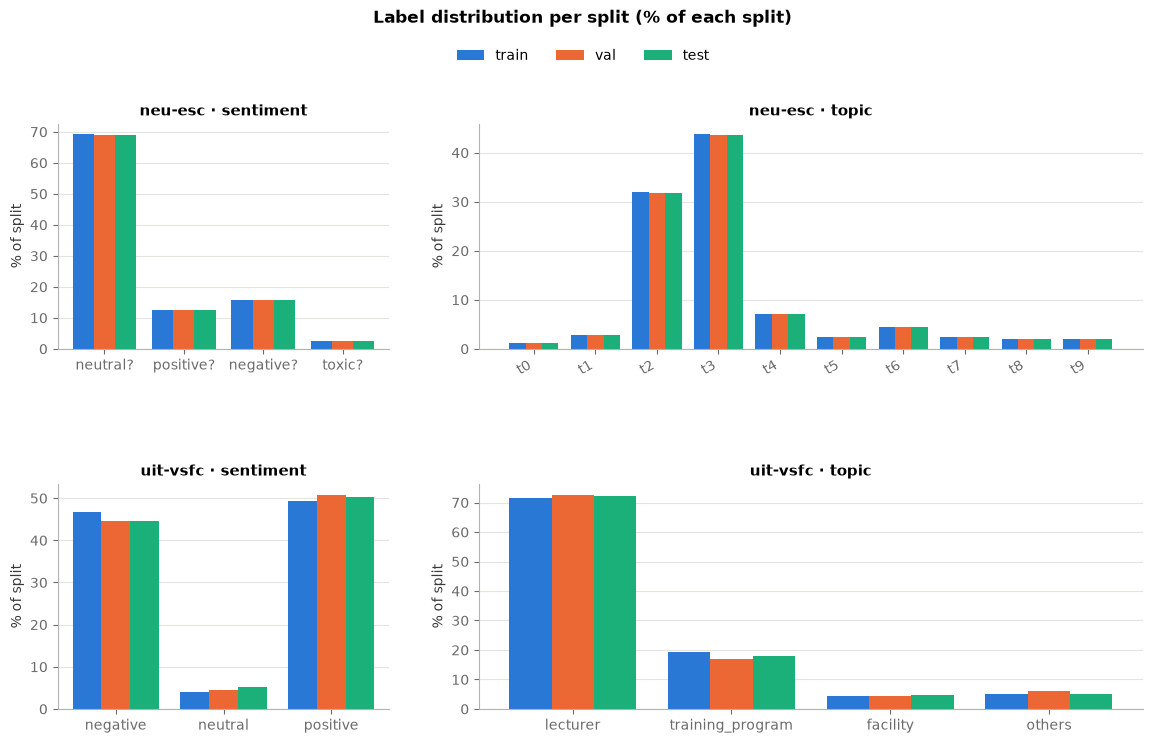

,dataset,task,label_id,label,train,val,test
0,neu-esc,sentiment,0,neutral?,69.142659,68.956127,68.924845
1,neu-esc,sentiment,1,positive?,12.569420,12.617247,12.611523
2,neu-esc,sentiment,2,negative?,15.749740,15.854766,15.817330
3,neu-esc,sentiment,3,toxic?,2.538181,2.571861,2.646303
4,neu-esc,topic,0,t0,1.219195,1.210287,1.270225
5,neu-esc,topic,1,t1,2.724748,2.753404,2.767277
6,neu-esc,topic,2,t2,31.911663,31.860817,31.816120
7,neu-esc,topic,3,t3,43.726137,43.630862,43.580826
8,neu-esc,topic,4,t4,7.145956,7.170953,7.167700
9,neu-esc,topic,5,t5,2.447067,2.450832,2.464842


In [6]:
from scipy.stats import chi2_contingency, entropy
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import accuracy_score, f1_score


def class_counts(labels, C):
    return np.bincount(np.asarray(labels, dtype=int), minlength=C)


def compare_dists(c1, c2):
    """Chi-square p and Jensen-Shannon distance (base 2) between two count vectors; classes absent from both are dropped."""
    keep = (c1 + c2) > 0
    a, b = c1[keep], c2[keep]
    p = chi2_contingency(np.vstack([a, b]))[1] if keep.sum() > 1 else float('nan')
    return float(p), float(jensenshannon(a / a.sum(), b / b.sum(), base=2))


pct_rows, imb_rows, JSD = [], [], {}
for ds in DATASETS:
    d = df[rows_of(ds)]
    SUMMARY['labels'][ds], SUMMARY['recommend']['loss'][ds] = {}, {}
    for task in TASKS:
        C, names = N_CLASSES[(ds, task)], NAMES[(ds, task)]
        cnt = {sp: class_counts(d.loc[d['split'] == sp, task], C) for sp in SPLITS}
        for c in range(C):
            pct_rows.append({'dataset': ds, 'task': task, 'label_id': c, 'label': names[c],
                             **{sp: 100 * cnt[sp][c] / cnt[sp].sum() for sp in SPLITS}})

        tr = cnt['train']
        N = int(tr.sum())
        ir = float(tr.max() / tr.min())
        norm_entropy = float(entropy(tr / N) / np.log(C))
        weights = N / (C * np.maximum(tr, 1))
        cmp = {sp: compare_dists(tr, cnt[sp]) for sp in ('val', 'test')}
        for sp in ('val', 'test'):
            JSD[(ds, task, sp)] = cmp[sp][1]

        maj = int(tr.argmax())
        y_test = d.loc[d['split'] == 'test', task].to_numpy()
        y_pred = np.full_like(y_test, maj)
        acc = float(accuracy_score(y_test, y_pred))
        mf1 = float(f1_score(y_test, y_pred, average='macro', labels=list(range(C)), zero_division=0))
        loss = 'ce' if ir < 3 else ('weighted_ce' if ir <= 10 else 'focal')

        imb_rows.append({
            'dataset': ds, 'task': task, 'classes': C, 'n_train': N, 'majority_class': names[maj],
            'imbalance_ratio': ir, 'norm_entropy': norm_entropy,
            'class_weights': ', '.join(f'{w:.2f}' for w in weights),
            'chi2_p_val': cmp['val'][0], 'jsd_val': cmp['val'][1],
            'chi2_p_test': cmp['test'][0], 'jsd_test': cmp['test'][1],
            'majority_acc_test': acc, 'majority_macro_f1_test': mf1, 'recommended_loss': loss,
        })
        SUMMARY['labels'][ds][task] = {
            'names': names, 'confirmed': bool(NAMES_CONFIRMED.get(ds, False)),
            'train_counts': tr, 'imbalance_ratio': ir, 'norm_entropy': norm_entropy,
            'class_weights': weights,
            'majority_baseline_test': {'accuracy': acc, 'macro_f1': mf1},
            'jsd_train_val': cmp['val'][1], 'jsd_train_test': cmp['test'][1],
        }
        SUMMARY['recommend']['loss'][ds][task] = loss
        if cmp['test'][1] > 0.05:
            warn(f'{ds} {task}: train vs test label JSD = {cmp["test"][1]:.3f} (> 0.05)')

label_pct = save_table(pd.DataFrame(pct_rows), 'tab_02_label_pct', show=False)
imbalance = save_table(pd.DataFrame(imb_rows), 'tab_03_imbalance')

fig, axes = plt.subplots(2, 2, figsize=(14, 7.6), gridspec_kw={'width_ratios': [1, 2], 'hspace': 0.6, 'wspace': 0.18})
bar_w = 0.8 / len(SPLITS)
for i, ds in enumerate(DATASETS):
    for j, task in enumerate(TASKS):
        ax = axes[i, j]
        sub = label_pct[(label_pct['dataset'] == ds) & (label_pct['task'] == task)]
        x = np.arange(len(sub))
        for k, sp in enumerate(SPLITS):
            ax.bar(x + (k - 1) * bar_w, sub[sp], width=bar_w, color=SPLIT_COLORS[sp], label=sp)
        ax.set_xticks(x, sub['label'])
        if len(sub) > 4:
            plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
        ax.set_ylabel('% of split')
        ax.set_title(f'{ds} · {task}')
        ax.grid(axis='x', visible=False)
handles, labels_ = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.995))
fig.suptitle('Label distribution per split (% of each split)', y=1.03, fontweight='bold', fontsize=12)
save_fig(fig, 'fig_01_label_dist')
display(label_pct)

**Reading this section.** With tens of thousands of rows, the chi-square p-value flags even tiny differences, so read the **Jensen–Shannon distance** (0 = identical, > 0.05 = worth a look) to judge split shift. The majority baseline shows why **macro-F1 is reported next to accuracy**: a model that always predicts the largest class can have high accuracy and very low macro-F1.

## 5. Sentiment × topic dependence
Per dataset on train: the topic × sentiment table, **bias-corrected Cramér's V** (Bergsma 2013), **normalized mutual information**, and the chi-square p-value. The heatmap shows P(sentiment | topic): each row sums to 1.

**Decision:** evidence for the MTL premise (the two tasks share information).

,cramers_v,nmi,chi2_p,strength
neu-esc,0.176822,0.034443,0.0,weak
uit-vsfc,0.351765,0.132577,0.0,strong


,dataset,topic,sentiment,train_count
0,neu-esc,t0,negative?,1
1,neu-esc,t1,toxic?,2
2,neu-esc,t5,toxic?,1
3,neu-esc,t8,toxic?,1
4,neu-esc,t9,toxic?,0


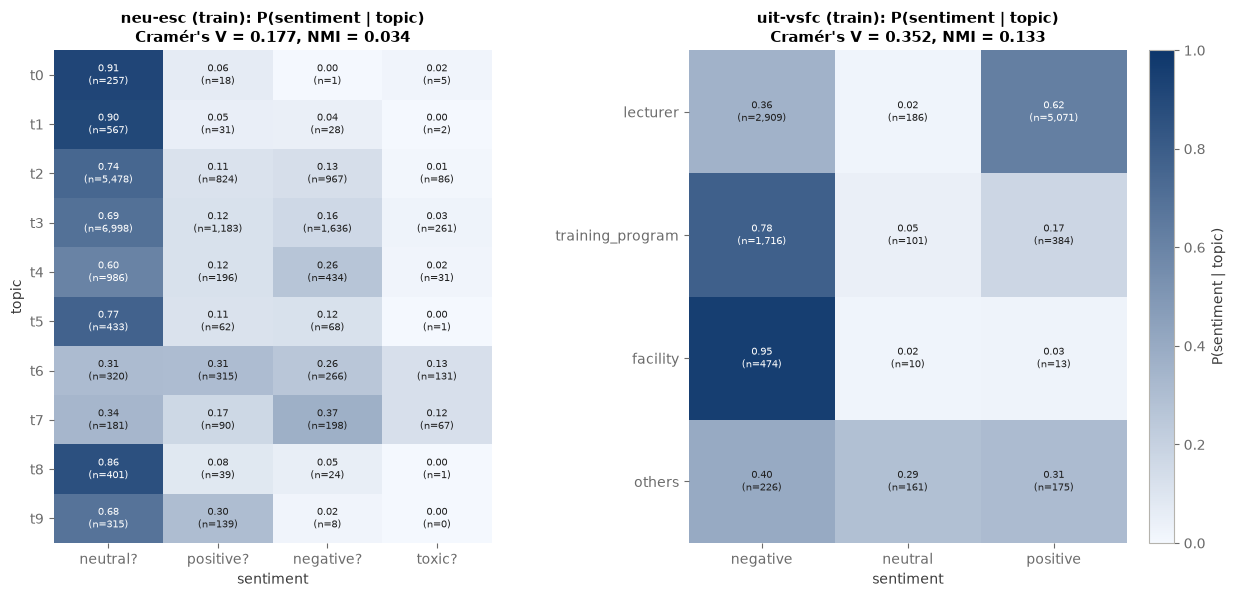

In [7]:
from sklearn.metrics import normalized_mutual_info_score


def cramers_v_corrected(table):
    """Bias-corrected Cramér's V (Bergsma 2013). All-zero rows/cols are dropped; NaN if < 2 rows or cols remain."""
    t = np.asarray(table, dtype=float)
    t = t[t.sum(axis=1) > 0][:, t.sum(axis=0) > 0]
    r, k = t.shape
    if r < 2 or k < 2:
        return float('nan')
    n = t.sum()
    chi2 = chi2_contingency(t, correction=False)[0]
    phi2c = max(0.0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc = r - (r - 1) ** 2 / (n - 1)
    kc = k - (k - 1) ** 2 / (n - 1)
    denom = min(kc - 1, rc - 1)
    return float(np.sqrt(phi2c / denom)) if denom > 0 else float('nan')


def strength(v):
    if not np.isfinite(v):
        return 'n/a'
    return 'negligible' if v < 0.1 else 'weak' if v < 0.2 else 'moderate' if v < 0.3 else 'strong'


JOINT, rare_rows = {}, []
for ds in DATASETS:
    tr = df[rows_of(ds, 'train')]
    Ct, Cs = N_CLASSES[(ds, 'topic')], N_CLASSES[(ds, 'sentiment')]
    ct = pd.crosstab(tr['topic'], tr['sentiment']).reindex(index=range(Ct), columns=range(Cs), fill_value=0)
    t = ct.to_numpy()
    kept = t[t.sum(axis=1) > 0][:, t.sum(axis=0) > 0]
    v = cramers_v_corrected(t)
    nmi = float(normalized_mutual_info_score(tr['topic'], tr['sentiment']))
    p = float(chi2_contingency(kept, correction=False)[1]) if min(kept.shape) >= 2 else float('nan')
    SUMMARY['task_dependence'][ds] = {'cramers_v': v, 'nmi': nmi, 'chi2_p': p, 'strength': strength(v)}

    named = ct.copy()
    named.index = pd.Index(NAMES[(ds, 'topic')], name='topic')
    named.columns = NAMES[(ds, 'sentiment')]
    JOINT[ds] = named
    save_table(named, f'tab_04_joint_counts_{ds}', show=False)
    for ti in range(Ct):
        for si in range(Cs):
            if t[ti, si] < 5:
                rare_rows.append({'dataset': ds, 'topic': NAMES[(ds, 'topic')][ti],
                                  'sentiment': NAMES[(ds, 'sentiment')][si], 'train_count': int(t[ti, si])})

display(pd.DataFrame(SUMMARY['task_dependence']).T)
save_table(pd.DataFrame(rare_rows, columns=['dataset', 'topic', 'sentiment', 'train_count']), 'tab_05_rare_combos')

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.4), gridspec_kw={'wspace': 0.45})
for ax, ds in zip(axes, DATASETS):
    ct = JOINT[ds]
    P = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0).to_numpy()
    im = ax.imshow(P, cmap=BLUES, vmin=0, vmax=1, aspect='auto')
    for r in range(P.shape[0]):
        for c in range(P.shape[1]):
            ax.text(c, r, f'{P[r, c]:.2f}\n(n={ct.iat[r, c]:,})', ha='center', va='center', fontsize=7.5,
                    color='white' if P[r, c] > 0.55 else INK)
    ax.set_xticks(range(P.shape[1]), ct.columns)
    ax.set_yticks(range(P.shape[0]), ct.index)
    ax.set_xlabel('sentiment')
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    dep = SUMMARY['task_dependence'][ds]
    ax.set_title(f"{ds} (train): P(sentiment | topic)\nCramér's V = {dep['cramers_v']:.3f}, NMI = {dep['nmi']:.3f}")
axes[0].set_ylabel('topic')
fig.colorbar(im, ax=list(axes), fraction=0.025, pad=0.02, label='P(sentiment | topic)')
save_fig(fig, 'fig_02_joint_heatmap')

**Reading this section.** V ≈ 0 means the labels are nearly independent: any MTL gain must come from **shared representations**, not from one task hinting the other. V ≈ 0.1–0.3 is a **moderate dependence** that supports the MTL premise. Rare combinations (< 5 train examples) are where the model has almost no joint evidence.

## 6. Lengths and `max_length`
### 6.1 Words and characters
Texts are already space-tokenized, so `n_words = len(text.split())`.

**Decision:** a first view of how long texts are, before subword tokenization.

,dataset,split,n_words_mean,n_words_median,n_words_p90,n_words_p95,n_words_p99,n_words_max,n_chars_mean,n_chars_median,n_chars_p90,n_chars_p95,n_chars_p99,n_chars_max
0,neu-esc,train,24.813259,12.0,49.0,81.0,207.53,1578,103.438216,49.0,208.0,347.0,901.00,6815
1,neu-esc,val,25.124054,12.0,52.0,82.0,229.76,832,105.136460,48.0,222.6,355.4,1001.76,3596
2,neu-esc,test,26.022078,12.0,50.8,89.0,242.88,1468,108.825798,49.0,215.0,381.0,1068.28,6244
3,uit-vsfc,train,14.308769,11.0,26.0,33.0,52.00,159,59.084894,47.0,110.0,141.0,218.75,660
4,uit-vsfc,val,13.671510,11.0,25.0,31.0,46.00,161,56.361971,45.0,105.8,132.0,196.18,718
5,uit-vsfc,test,14.220783,11.0,26.0,34.0,52.35,98,58.836387,46.0,111.0,147.0,221.35,411


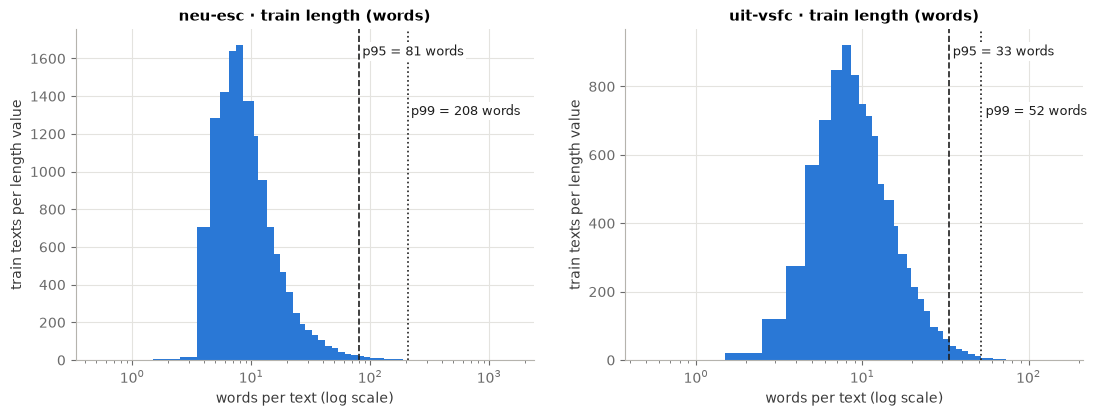

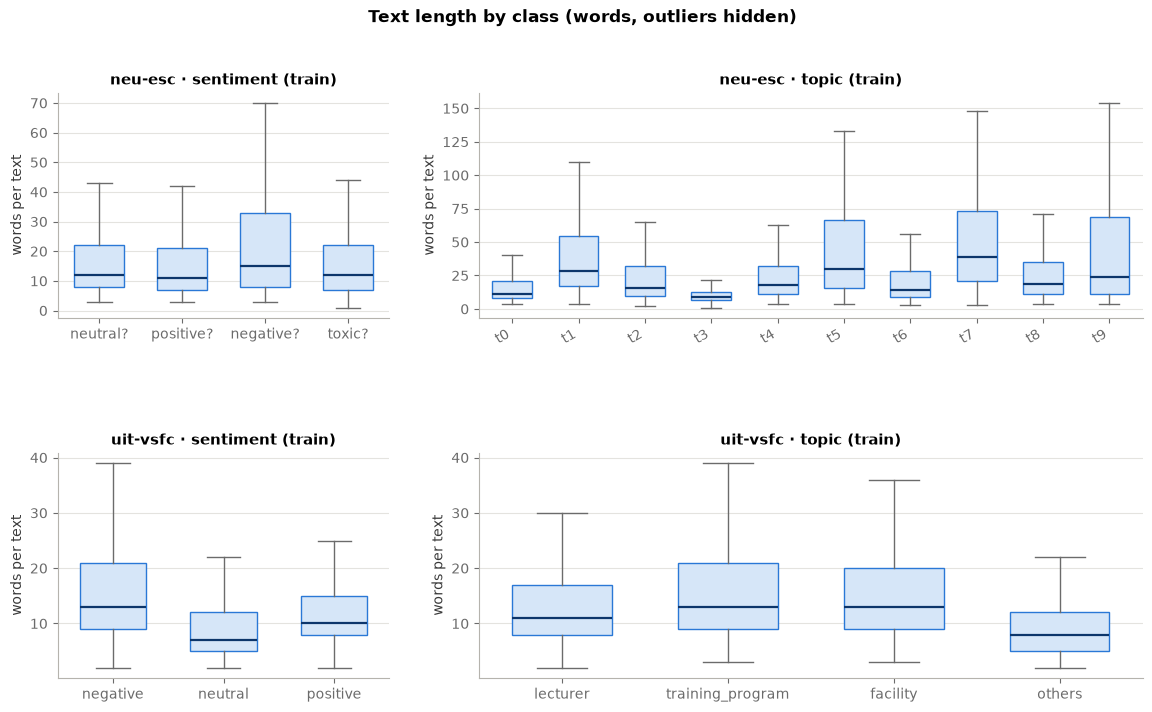

In [8]:
def pct_fn(q):
    f = lambda s: s.quantile(q)
    f.__name__ = f'p{int(round(q * 100))}'
    return f


length_stats = (df.groupby(['dataset', 'split'], observed=True)[['n_words', 'n_chars']]
                .agg(['mean', 'median', pct_fn(0.90), pct_fn(0.95), pct_fn(0.99), 'max']))
save_table(length_stats, 'tab_06_length_stats')

for ds in DATASETS:
    x = df.loc[rows_of(ds, 'train'), 'n_words']
    SUMMARY['lengths'][ds] = {'n_words_p95_train': float(x.quantile(0.95)),
                              'n_words_p99_train': float(x.quantile(0.99)),
                              'n_words_max': int(x.max())}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, ds in zip(axes, DATASETS):
    x = df.loc[rows_of(ds, 'train'), 'n_words'].to_numpy()
    edges = np.unique(np.round(np.logspace(0, np.log10(x.max() + 1), 60))) - 0.5   # integer-aligned log bins
    hist, _ = np.histogram(x, bins=edges)
    ax.stairs(hist / np.diff(edges), edges, fill=True, color=SPLIT_COLORS['train'])   # per length value: bins differ in width
    ax.set_xscale('log')
    p95, p99 = np.percentile(x, [95, 99])
    top, xmax = ax.get_ylim()[1], ax.get_xlim()[1]
    for val, style, frac, lab in ((p95, '--', 0.92, 'p95'), (p99, ':', 0.74, 'p99')):
        ax.axvline(val, color=INK, ls=style, lw=1.2)
        right_side = val * 4 < xmax
        ax.text(val * (1.06 if right_side else 1 / 1.06), top * frac, f'{lab} = {val:.0f} words',
                ha='left' if right_side else 'right', fontsize=9, color=INK,
                bbox=dict(facecolor='white', edgecolor='none', pad=1.5))
    ax.set_xlabel('words per text (log scale)')
    ax.set_ylabel('train texts per length value')
    ax.set_title(f'{ds} · train length (words)')
save_fig(fig, 'fig_03_length_hist')

fig, axes = plt.subplots(2, 2, figsize=(14, 7.6), gridspec_kw={'width_ratios': [1, 2], 'hspace': 0.6, 'wspace': 0.18})
for i, ds in enumerate(DATASETS):
    tr = df[rows_of(ds, 'train')]
    for j, task in enumerate(TASKS):
        ax = axes[i, j]
        C = N_CLASSES[(ds, task)]
        data = [tr.loc[tr[task] == c, 'n_words'].to_numpy() for c in range(C)]
        ax.boxplot(data, tick_labels=NAMES[(ds, task)], showfliers=False, patch_artist=True, widths=0.6,
                   boxprops=dict(facecolor='#d6e6f8', edgecolor=SPLIT_COLORS['train']),
                   medianprops=dict(color='#0d366b', lw=1.6),
                   whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
        if C > 4:
            plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
        ax.set_ylabel('words per text')
        ax.set_title(f'{ds} · {task} (train)')
        ax.grid(axis='x', visible=False)
fig.suptitle('Text length by class (words, outliers hidden)', y=0.99, fontweight='bold', fontsize=12)
save_fig(fig, 'fig_04_length_by_class')

### 6.2 Subword token lengths
Counted **with special tokens and no truncation**, the way each model sees the text. PhoBERT gets **word-segmented** text (`segment_words`, cached). Token lengths are cached per tokenizer, so a re-run skips tokenizing. A tokenizer that fails to load is recorded as a warning and skipped.

**Decision:** `max_length = min(model_limit, ceil(p95 / 16) · 16)` per (dataset, model), and how much each class is cut at that length.

In [9]:
TOKLEN, TOK_STATUS = {}, {}      # model -> float array aligned to df rows (NaN = not measured); model -> how obtained
TOK_BATCH = 1000


def safe_name(name):
    return re.sub(r'[^A-Za-z0-9._-]+', '_', name)


if TOKEN_SAMPLE:
    SAMPLE_MASK = np.zeros(len(df), dtype=bool)
    for _, g in df.groupby(['dataset', 'split'], observed=True):
        SAMPLE_MASK[RNG.choice(g.index.to_numpy(), size=min(TOKEN_SAMPLE, len(g)), replace=False)] = True
else:
    SAMPLE_MASK = np.ones(len(df), dtype=bool)


def segmented_text():
    """Word-segmented text for PhoBERT, aligned to df rows; cached per (dataset, split) as cache/<ds>_<split>_seg.csv."""
    out = np.empty(len(df), dtype=object)
    for (ds, sp), g in df.groupby(['dataset', 'split'], observed=True):
        path = CACHE / f'{ds}_{sp}_seg.csv'
        seg = None
        if path.exists():
            cached = pd.read_csv(path, encoding='utf-8', keep_default_na=False, dtype={'text_seg': str})
            if len(cached) == len(g):
                seg = cached['text_seg'].tolist()
        if seg is None:
            t0 = time.time()
            seg = segment_words(g['text'].tolist())
            pd.DataFrame({'idx': g['idx'].to_numpy(), 'text_seg': seg}).to_csv(path, index=False, encoding='utf-8')
            print(f'  segmented {ds}/{sp}: {len(g):,} texts in {time.time() - t0:.0f}s')
        out[g.index.to_numpy()] = seg
    return out


def load_tokenizer(name):
    from transformers import AutoTokenizer
    try:
        return AutoTokenizer.from_pretrained(name, use_fast=False), 'slow'
    except Exception as slow_err:
        try:
            return AutoTokenizer.from_pretrained(name, use_fast=True), 'fast'
        except Exception as fast_err:
            raise RuntimeError(f'slow: {type(slow_err).__name__}; fast: {type(fast_err).__name__}: {fast_err}') from None


def count_tokens(tok, texts):
    lengths = []
    for i in range(0, len(texts), TOK_BATCH):
        enc = tok(texts[i:i + TOK_BATCH], add_special_tokens=True, truncation=False)
        lengths += [len(ids) for ids in enc['input_ids']]
    return lengths


SEG = None
transformers = None
if RUN_TOKENS:
    try:
        import transformers
        transformers.logging.set_verbosity_error()
    except Exception as e:
        warn(f'transformers not available ({type(e).__name__}); subword lengths skipped')
        transformers = None

if transformers is not None:
    for name in TOKENIZERS:
        path = CACHE / f'toklen_{safe_name(name)}.csv'
        lengths = None
        if path.exists():
            vals = pd.read_csv(path)['n_tokens'].to_numpy(dtype=float)
            if len(vals) == len(df) and not np.isnan(vals[SAMPLE_MASK]).any():   # cache covers every needed row
                lengths = vals
                TOK_STATUS[name] = 'reused cache'
        if lengths is None:
            try:
                t0 = time.time()
                tok, kind = load_tokenizer(name)
                if 'phobert' in name.lower():
                    if SEG is None:
                        SEG = segmented_text()
                    source = SEG
                else:
                    source = df['text'].to_numpy(dtype=object)
                pos = np.flatnonzero(SAMPLE_MASK)
                lengths = np.full(len(df), np.nan)
                lengths[pos] = count_tokens(tok, [str(source[i]) for i in pos])
                pd.DataFrame({'dataset': df['dataset'], 'split': df['split'].astype(str), 'idx': df['idx'],
                              'n_tokens': lengths}).to_csv(path, index=False)
                TOK_STATUS[name] = f'{kind} tokenizer, {time.time() - t0:.0f}s'
            except Exception as e:
                warn(f'tokenizer {name!r} skipped: {type(e).__name__}: {" ".join(str(e).split())[:200]}')
                TOK_STATUS[name] = 'failed'
                continue
        lengths = lengths.copy()
        lengths[~SAMPLE_MASK] = np.nan
        TOKLEN[name] = lengths
elif not RUN_TOKENS:
    print('RUN_TOKENS = False: subword token lengths skipped.')

SUMMARY['tokenizer_status'] = TOK_STATUS
display(pd.Series(TOK_STATUS, name='status', dtype=object).to_frame())

,status
vinai/phobert-base-v2,reused cache
xlm-roberta-base,reused cache
bert-base-multilingual-cased,reused cache


,dataset,tokenizer,n_train,p50,p90,p95,p99,max,trunc%@64,trunc%@96,trunc%@128,trunc%@192,trunc%@256,trunc%@512,recommended_max_length,trunc%@rec
0,neu-esc,vinai/phobert-base-v2,23048,14.0,47.0,76.0,190.00,1343.0,6.351961,3.414613,1.978480,0.980562,0.611767,NaN,80,4.586081
1,neu-esc,xlm-roberta-base,23048,17.0,58.0,94.0,231.00,1748.0,8.378167,4.763971,2.967720,1.423117,0.880771,0.212600,96,4.763971
2,neu-esc,bert-base-multilingual-cased,23048,17.0,60.0,97.0,241.06,1869.0,8.942208,5.050330,3.158625,1.518570,0.911142,0.234294,112,3.961298
3,uit-vsfc,vinai/phobert-base-v2,11426,11.0,24.0,30.0,46.00,129.0,0.236303,0.017504,0.008752,0.000000,0.000000,NaN,32,3.964642
4,uit-vsfc,xlm-roberta-base,11426,15.0,31.0,39.0,59.00,179.0,0.726413,0.078768,0.017504,0.000000,0.000000,0.000000,48,2.336776
5,uit-vsfc,bert-base-multilingual-cased,11426,14.0,30.5,38.0,58.00,176.0,0.673902,0.087520,0.017504,0.000000,0.000000,0.000000,48,2.152984


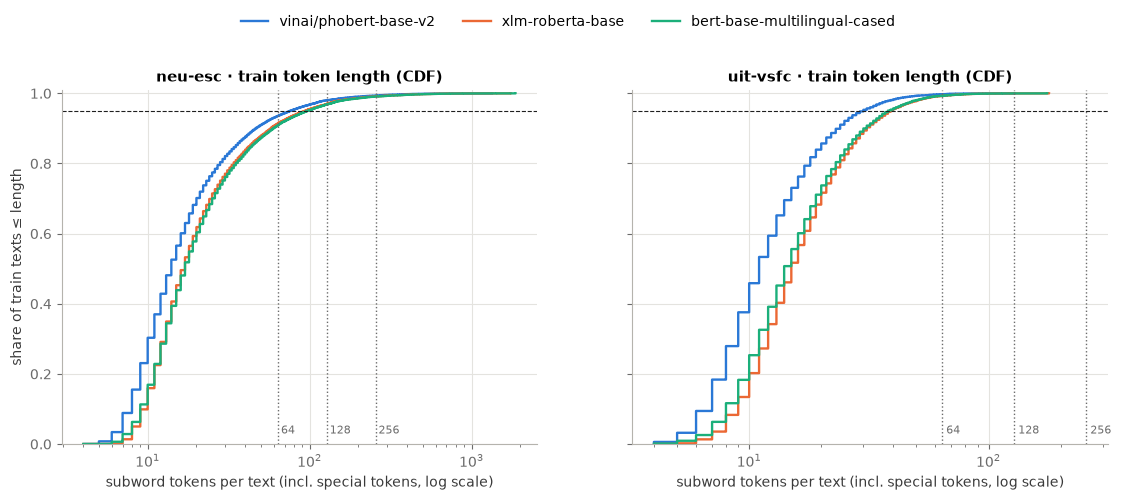

Recommended max_length (rows = model, columns = dataset):


,neu-esc,uit-vsfc
vinai/phobert-base-v2,80,32
xlm-roberta-base,96,48
bert-base-multilingual-cased,112,48


In [10]:
THRESHOLDS = (64, 96, 128, 192, 256, 512)
cov_rows, cls_rows = [], []
for ds in DATASETS:
    tr_mask = rows_of(ds, 'train').to_numpy()
    SUMMARY['tokens'][ds], SUMMARY['recommend']['max_length'][ds] = {}, {}
    for name, lengths in TOKLEN.items():
        m = tr_mask & ~np.isnan(lengths)
        x = lengths[m]
        if not len(x):
            continue
        limit = TOKENIZERS[name]
        p50, p90, p95, p99 = np.percentile(x, [50, 90, 95, 99])
        rec = int(min(limit, math.ceil(p95 / 16) * 16))
        trunc = {t: float(100 * (x > t).mean()) for t in THRESHOLDS if t <= limit}
        trunc_rec = float(100 * (x > rec).mean())
        cov_rows.append({'dataset': ds, 'tokenizer': name, 'n_train': int(len(x)), 'p50': p50, 'p90': p90,
                         'p95': p95, 'p99': p99, 'max': float(x.max()),
                         **{f'trunc%@{t}': trunc.get(t, np.nan) for t in THRESHOLDS},
                         'recommended_max_length': rec, 'trunc%@rec': trunc_rec})
        SUMMARY['tokens'][ds][name] = {'p50': p50, 'p95': p95, 'p99': p99, 'max': float(x.max()),
                                       'recommended': rec, 'trunc_pct_at_rec': trunc_rec,
                                       'trunc_pct_at': {str(t): v for t, v in trunc.items()}}
        SUMMARY['recommend']['max_length'][ds][name] = rec
        for task in TASKS:
            labels_ = df[task].to_numpy()[m]
            for c in range(N_CLASSES[(ds, task)]):
                sel = labels_ == c
                pct = float(100 * (x[sel] > rec).mean()) if sel.any() else float('nan')
                cls_rows.append({'dataset': ds, 'tokenizer': name, 'task': task, 'label': NAMES[(ds, task)][c],
                                 'n_train': int(sel.sum()), 'max_length': rec, 'trunc%': pct})
                if pct > 5:
                    warn(f'{ds} / {name}: {pct:.1f}% of {task}={NAMES[(ds, task)][c]} train texts are longer than max_length {rec}')

if cov_rows:
    save_table(pd.DataFrame(cov_rows), 'tab_07_token_coverage')
    save_table(pd.DataFrame(cls_rows), 'tab_08_trunc_by_class', show=False)

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), sharey=True)
    for ax, ds in zip(axes, DATASETS):
        tr_mask = rows_of(ds, 'train').to_numpy()
        for name, lengths in TOKLEN.items():
            x = np.sort(lengths[tr_mask & ~np.isnan(lengths)])
            if len(x):
                ax.plot(x, np.arange(1, len(x) + 1) / len(x), drawstyle='steps-post', lw=1.7,
                        color=SERIES_COLORS[list(TOKENIZERS).index(name) % len(SERIES_COLORS)], label=name)
        for t in (64, 128, 256):
            ax.axvline(t, color=MUTED, ls=':', lw=1)
            ax.text(t * 1.04, 0.03, str(t), color=MUTED, fontsize=8)
        ax.axhline(0.95, color=INK, ls='--', lw=0.8)
        ax.set_xscale('log')
        ax.set_ylim(0, 1.01)
        ax.set_xlabel('subword tokens per text (incl. special tokens, log scale)')
        ax.set_title(f'{ds} · train token length (CDF)')
    axes[0].set_ylabel('share of train texts ≤ length')
    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='upper center', ncol=len(labels_), bbox_to_anchor=(0.5, 1.07))
    save_fig(fig, 'fig_05_token_cdf')

    rec_table = pd.DataFrame(SUMMARY['recommend']['max_length'])
    print('Recommended max_length (rows = model, columns = dataset):')
    display(rec_table)
else:
    print('No tokenizer was measured: tab_07, tab_08 and fig_05 are skipped.')

### 6.3 Batch plan (estimate, no GPU run)
`start_batch = pow2_floor(base · 64 / max(L, 64))`, base 16 on the local 8 GB GPU and 32 on a Kaggle T4 (16 GB); gradient accumulation brings the effective batch to 32; fp16 (T4 has no bf16).

**Decision:** a starting batch size and accumulation per (dataset, model, GPU).

In [11]:
def pow2_floor(x):
    return 2 ** int(math.floor(math.log2(max(x, 1))))


GPUS = (('RTX 5050 Laptop 8 GB (local)', 16), ('T4 16 GB (Kaggle)', 32))
plan = []
for ds, per_model in SUMMARY['recommend']['max_length'].items():
    for name, L in per_model.items():
        for gpu, base in GPUS:
            start = pow2_floor(base * 64 / max(L, 64))
            accum = max(1, 32 // start)
            plan.append({'dataset': ds, 'tokenizer': name, 'max_length': L, 'gpu': gpu, 'start_batch': start,
                         'grad_accum': accum, 'effective_batch': start * accum, 'precision': 'fp16'})
SUMMARY['recommend']['batch_plan'] = plan
if plan:
    save_table(pd.DataFrame(plan), 'tab_09_batch_plan')
else:
    print('No recommended max_length (no tokenizer measured): batch plan skipped.')

,dataset,tokenizer,max_length,gpu,start_batch,grad_accum,effective_batch,precision
0,neu-esc,vinai/phobert-base-v2,80,RTX 5050 Laptop 8 GB (local),8,4,32,fp16
1,neu-esc,vinai/phobert-base-v2,80,T4 16 GB (Kaggle),16,2,32,fp16
2,neu-esc,xlm-roberta-base,96,RTX 5050 Laptop 8 GB (local),8,4,32,fp16
3,neu-esc,xlm-roberta-base,96,T4 16 GB (Kaggle),16,2,32,fp16
4,neu-esc,bert-base-multilingual-cased,112,RTX 5050 Laptop 8 GB (local),8,4,32,fp16
5,neu-esc,bert-base-multilingual-cased,112,T4 16 GB (Kaggle),16,2,32,fp16
6,uit-vsfc,vinai/phobert-base-v2,32,RTX 5050 Laptop 8 GB (local),16,2,32,fp16
7,uit-vsfc,vinai/phobert-base-v2,32,T4 16 GB (Kaggle),32,1,32,fp16
8,uit-vsfc,xlm-roberta-base,48,RTX 5050 Laptop 8 GB (local),16,2,32,fp16
9,uit-vsfc,xlm-roberta-base,48,T4 16 GB (Kaggle),32,1,32,fp16


**Reading this section.** These are starting points, not measurements. The reference repo reports about **10–11 GB at batch 32, length 64** with SMART, so the local 8 GB GPU needs small batches plus accumulation. The trainer should measure the real memory limit on the first steps and adjust.

## 7. Vocabulary and distinctive words
Tokens are `text.split()`. OOV = tokens of val/test never seen in the same dataset's train split.

**Decision:** how much unseen vocabulary the model faces, how different the two datasets are, and what the unnamed NEU-ESC topics `t0`…`t9` are about.

In [12]:
from collections import Counter

TOKS = df['text'].str.split()
vocab_rows, TRAIN_VOCAB, OOV_TOK = [], {}, {}
for ds in DATASETS:
    counters = {sp: Counter(t for toks in TOKS[rows_of(ds, sp)] for t in toks) for sp in SPLITS}
    train_types = set(counters['train'])
    TRAIN_VOCAB[ds] = train_types
    for sp in SPLITS:
        c = counters[sp]
        n_tokens = sum(c.values())
        oov = [t for t in c if t not in train_types]
        oov_types_pct = 0.0 if sp == 'train' else 100 * len(oov) / len(c)
        oov_tokens_pct = 0.0 if sp == 'train' else 100 * sum(c[t] for t in oov) / n_tokens
        OOV_TOK[(ds, sp)] = oov_tokens_pct
        vocab_rows.append({'dataset': ds, 'split': sp, 'types': len(c), 'tokens': n_tokens,
                           'oov_types_pct': oov_types_pct, 'oov_tokens_pct': oov_tokens_pct})
vocab = save_table(pd.DataFrame(vocab_rows), 'tab_10_vocab')

A, B = TRAIN_VOCAB['neu-esc'], TRAIN_VOCAB['uit-vsfc']
cross = {'shared_types': len(A & B), 'jaccard': len(A & B) / len(A | B),
         'pct_uit_types_in_neu': 100 * len(A & B) / len(B), 'pct_neu_types_in_uit': 100 * len(A & B) / len(A)}
SUMMARY['vocab'] = {'splits': vocab.to_dict('records'), 'cross_dataset_train': cross}
print('Train vocabulary overlap between datasets:')
display(pd.Series(cross).to_frame('value'))

,dataset,split,types,tokens,oov_types_pct,oov_tokens_pct
0,neu-esc,train,11103,571896,0.000000,0.000000
1,neu-esc,val,4956,83035,11.380145,0.782802
2,neu-esc,test,6810,172084,18.046990,0.928035
3,uit-vsfc,train,2514,163492,0.000000,0.000000
4,uit-vsfc,val,1157,21642,9.420916,0.526754
5,uit-vsfc,test,1581,45023,16.824794,0.650778


Train vocabulary overlap between datasets:


,value
shared_types,1934.000000
jaccard,0.165540
pct_uit_types_in_neu,76.929196
pct_neu_types_in_uit,17.418716


**Top words per class.** Weighted log-odds with an informative Dirichlet prior (Monroe et al. 2008): each class against the rest, prior = corpus word distribution scaled to α₀ = 1000, ranked by z-score, words with at least 5 train occurrences. Unlike raw frequency, this ignores words that are common everywhere. For NEU-ESC this is **how to guess what `t0`…`t9` mean**.

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

ALPHA0, MIN_COUNT, TOP_K = 1000, 5, 15


def log_odds_top(texts, labels, C, k=TOP_K):
    vec = CountVectorizer(token_pattern=r'\S+', lowercase=False)
    X = vec.fit_transform(texts).tocsr()
    words = vec.get_feature_names_out()
    total = np.asarray(X.sum(axis=0)).ravel()
    keep = total >= MIN_COUNT
    X, words, total = X[:, keep], words[keep], total[keep].astype(float)
    alpha = ALPHA0 * total / total.sum()
    a0 = alpha.sum()
    out = {}
    for c in range(C):
        yi = np.asarray(X[labels == c].sum(axis=0)).ravel().astype(float)
        yj = total - yi
        ni, nj = yi.sum(), yj.sum()
        delta = (np.log((yi + alpha) / (ni + a0 - yi - alpha))
                 - np.log((yj + alpha) / (nj + a0 - yj - alpha)))
        z = delta / np.sqrt(1 / (yi + alpha) + 1 / (yj + alpha))
        order = np.argsort(-z)[:k]
        out[c] = [(words[i], float(z[i]), int(yi[i])) for i in order]
    return out


top_rows = []
for ds in DATASETS:
    tr = df[rows_of(ds, 'train')]
    for task in TASKS:
        tops = log_odds_top(tr['text'].tolist(), tr[task].to_numpy(), N_CLASSES[(ds, task)])
        for c, items in tops.items():
            for rank, (w, z, n) in enumerate(items, 1):
                top_rows.append({'dataset': ds, 'task': task, 'label': NAMES[(ds, task)][c],
                                 'rank': rank, 'word': w, 'z': z, 'count_in_class': n})
top_words = save_table(pd.DataFrame(top_rows), 'tab_11_top_words', show=False)
compact = (top_words.groupby(['dataset', 'task', 'label'], sort=False)['word']
           .apply(lambda s: ', '.join(s)).rename('top words (by z)').reset_index())
display(compact)

,dataset,task,label,top words (by z)
0,neu-esc,sentiment,neutral?,"ạ, học, ngành, kinh, tuyển, toán, ký, môn, tế, đăng, thi, xét, pass, inbox, luật"
1,neu-esc,sentiment,positive?,"chúc, đẹp, mừng, yêu, vui, xinh, ngon, thầy, mê, tuyệt, neu, giỏi, ynm, siêu, thành"
2,neu-esc,sentiment,negative?,"sợ, buồn, lỗi, sai, bị, chửi, vãi, không, xấu, khóc, nói, mà, chán, trượt, khổ"
3,neu-esc,sentiment,toxic?,"mẹ, mày, đéo, con, thằng, địt, tao, chó, ngu, vãi, nó, lồn, dựa, nạn, cái"
4,neu-esc,topic,t0,"inbox, mos, like, check, ghép, đãi, bơ, facebook, giá, nhu, gaming, nhé, chấm, khóa, quảng"
5,neu-esc,topic,t1,"tuyển, xét, báo, thông, đại, quốc, and, kết, trúng, of, thí, 2023, the, tạp, sinh"
6,neu-esc,topic,t2,"học, môn, ngành, thi, thầy, ạ, toán, lớp, giáo, kì, pass, luật, trình, pháp, dạy"
7,neu-esc,topic,t3,"., đi, trai, đấy, mà, à, thôi, ăn, quá, vãi, kìa, cậu, yêu, ngủ, nè"
8,neu-esc,topic,t4,"phòng, xe, xá, túc, kí, máy, cổng, chỗ, thang, tầng, gửi, trọ, canteen, trường, đồ"
9,neu-esc,topic,t5,"lương, việc, công, ca, nghề, tuyển, hàng, nghiệp, time, thực, nghiệm, năng, ty, xoay, ngân"


**UIT-VSFC emoticon words.** The UIT-VSFC authors replaced emoticons with letter-only words (`:)` → `colonsmile`, see `datasets/uit-vsfc/README.txt`). A subword tokenizer splits these into meaningless pieces.

**Decision:** frequent ones should be mapped back to an emoji or one Vietnamese word before subword tokenization.

In [14]:
readme = DATA / 'uit-vsfc' / 'README.txt'
readme_words = {}
if readme.exists():
    in_acronyms = False
    for line in readme.read_text(encoding='utf-8', errors='replace').splitlines():
        if line.strip().startswith('D.'):
            in_acronyms = True
            continue
        parts_ = line.split()
        if in_acronyms and len(parts_) >= 2 and re.fullmatch(r'[a-z]+', parts_[-1]):
            sym = ' '.join(parts_[:-1])
            readme_words[parts_[-1]] = readme_words[parts_[-1]] + ' / ' + sym if parts_[-1] in readme_words else sym
else:
    warn(f'{readme} not found: emoticon list uses only the colon* pattern')

uit_tr = df[rows_of('uit-vsfc', 'train')]
uit_sets = [set(toks) for toks in TOKS[uit_tr.index]]
uit_counts = Counter(t for toks in TOKS[uit_tr.index] for t in toks)
candidates = sorted({t for t in uit_counts if re.fullmatch(r'colon[a-z]+', t)} | {'dotdotdot', 'fraction'} | set(readme_words))
sent = uit_tr['sentiment'].to_numpy()
emo_rows = []
for w in candidates:
    has = np.array([w in s for s in uit_sets])
    if not uit_counts[w]:
        continue
    row = {'word': w, 'symbol': readme_words.get(w, ''), 'count': uit_counts[w], 'texts': int(has.sum())}
    for c, n in enumerate(NAMES[('uit-vsfc', 'sentiment')]):
        row[f'pct_texts_{n}'] = float(100 * has[sent == c].mean())
    emo_rows.append(row)
emo_cols = ['word', 'symbol', 'count', 'texts'] + [f'pct_texts_{n}' for n in NAMES[('uit-vsfc', 'sentiment')]]
emoticons = pd.DataFrame(emo_rows, columns=emo_cols).sort_values('count', ascending=False)
save_table(emoticons, 'tab_12_uit_emoticons')
SUMMARY['uit_emoticons'] = {r['word']: {k: v for k, v in r.items() if k != 'word'} for r in emoticons.to_dict('records')}
unseen = [w for w in candidates if not uit_counts[w]]
print(f'{len(emoticons)} replacement words occur in UIT-VSFC train; {len(unseen)} listed words never occur: {unseen}')

,word,symbol,count,texts,pct_texts_negative,pct_texts_neutral,pct_texts_positive
0,doubledot,:,85,84,1.352113,1.528384,0.088605
1,colonsmile,:),27,27,0.150235,0.218341,0.318979
2,fraction,/,19,18,0.150235,1.310044,0.070884
3,colonsmilesmile,:d,12,12,0.075117,0.218341,0.124047
4,colonsad,:(,11,11,0.206573,0.000000,0.000000
5,coloncontemn,:3,9,9,0.037559,0.436681,0.088605
6,vdotv,v.v,8,8,0.131455,0.000000,0.017721
7,colonlove,<3,7,7,0.000000,0.000000,0.124047
8,colonbigsmile,:v,5,5,0.056338,0.000000,0.035442
9,dotdotdot,...,5,5,0.075117,0.000000,0.017721


16 replacement words occur in UIT-VSFC train; 3 listed words never occur: ['coloncc', 'colonlovelove', 'cshrap']


## 8. Duplicates, leakage, label conflicts
Texts are compared on `norm` = Unicode NFC + collapsed whitespace + strip (the `text` column itself is never changed).

**Decision:** cleaning rules, and how far test scores can be trusted.

In [15]:
def normalize_text(t):
    return re.sub(r'\s+', ' ', unicodedata.normalize('NFC', t)).strip()


df['norm'] = df['text'].map(normalize_text)

g = df.groupby(['dataset', 'split'], observed=True)['norm']
dups = pd.DataFrame({'rows': g.size(), 'unique_texts': g.nunique()})
dups['duplicate_rows'] = dups['rows'] - dups['unique_texts']
dups['duplicate_pct'] = 100 * dups['duplicate_rows'] / dups['rows']
save_table(dups, 'tab_13_duplicates')

PAIRS = (('train', 'val'), ('train', 'test'), ('val', 'test'))
leak_rows, leak_examples = [], []
for ds in DATASETS:
    by = {sp: df[rows_of(ds, sp)] for sp in SPLITS}
    SUMMARY['leakage'][ds] = {}
    for a, b in PAIRS:
        set_a = set(by[a]['norm'])
        in_a = by[b]['norm'].isin(set_a)
        rows_b = int(in_a.sum())
        pct = 100 * rows_b / len(by[b])
        leak_rows.append({'dataset': ds, 'pair': f'{a}∩{b}', 'shared_unique_texts': len(set_a & set(by[b]['norm'])),
                          'rows_in_second_split': rows_b, 'pct_of_second_split': pct})
        SUMMARY['leakage'][ds][f'{a}_{b}'] = pct
        for _, r in by[b][in_a].head(5).iterrows():
            leak_examples.append({'dataset': ds, 'pair': f'{a}∩{b}', 'split': b, 'idx': int(r['idx']),
                                  'text': r['text'][:200]})
    leaked = sorted(int(i) for i in by['test'].loc[by['test']['norm'].isin(set(by['train']['norm'])), 'idx'])
    path = CACHE / f'{ds}_test_leaked_idx.json'
    save_json({'dataset': ds, 'n_test': len(by['test']), 'n_leaked': len(leaked), 'test_leaked_idx': leaked}, path)
    SUMMARY['recommend']['test_leaked_idx_file'][ds] = path.relative_to(OUT).as_posix()

save_table(pd.DataFrame(leak_rows), 'tab_14_leakage')
save_table(pd.DataFrame(leak_examples, columns=['dataset', 'pair', 'split', 'idx', 'text']), 'tab_15_leakage_examples', show=False)

,dataset,split,rows,unique_texts,duplicate_rows,duplicate_pct
0,neu-esc,train,23048,23048,0,0.000000
1,neu-esc,val,3305,3305,0,0.000000
2,neu-esc,test,6613,6613,0,0.000000
3,uit-vsfc,train,11426,11425,1,0.008752
4,uit-vsfc,val,1583,1583,0,0.000000
5,uit-vsfc,test,3166,3166,0,0.000000


,dataset,pair,shared_unique_texts,rows_in_second_split,pct_of_second_split
0,neu-esc,train∩val,0,0,0.0
1,neu-esc,train∩test,0,0,0.0
2,neu-esc,val∩test,0,0,0.0
3,uit-vsfc,train∩val,0,0,0.0
4,uit-vsfc,train∩test,0,0,0.0
5,uit-vsfc,val∩test,0,0,0.0


,dataset,pair,split,idx,text


**Label conflicts:** the same normalized text (anywhere in the dataset) carrying different labels. On train this is annotation noise that caps achievable accuracy.

In [16]:
conf_rows, conf_examples = [], []
for ds in DATASETS:
    d = df[rows_of(ds)]
    n_train = int((d['split'] == 'train').sum())
    SUMMARY['label_conflicts'][ds] = {}
    for task in TASKS:
        nun = d.groupby('norm')[task].nunique()
        bad = set(nun.index[nun > 1])
        in_bad = d['norm'].isin(bad)
        train_rows = int((in_bad & (d['split'] == 'train')).sum())
        pct = 100 * train_rows / n_train
        conf_rows.append({'dataset': ds, 'task': task, 'conflicting_texts': len(bad),
                          'train_rows_involved': train_rows, 'pct_of_train': pct})
        SUMMARY['label_conflicts'][ds][task] = {'conflicting_texts': len(bad), 'train_rows': train_rows, 'pct_train': pct}
        if pct > 1:
            warn(f'{ds} {task}: {pct:.2f}% of train rows have a conflicting label on an identical text (> 1%)')
        worst = d[in_bad].groupby('norm').size().sort_values(ascending=False).head(10).index
        for norm_text in worst:
            grp = d[d['norm'] == norm_text]
            variants = '; '.join(sorted(f'{s}:{n}' for s, n in zip(grp['split'].astype(str), grp[f'{task}_name'])))
            conf_examples.append({'dataset': ds, 'task': task, 'text': norm_text[:200], 'variants': variants})

save_table(pd.DataFrame(conf_rows), 'tab_16_label_conflicts')
save_table(pd.DataFrame(conf_examples, columns=['dataset', 'task', 'text', 'variants']), 'tab_17_conflict_examples')

,dataset,task,conflicting_texts,train_rows_involved,pct_of_train
0,neu-esc,sentiment,0,0,0.000000
1,neu-esc,topic,0,0,0.000000
2,uit-vsfc,sentiment,1,2,0.017504
3,uit-vsfc,topic,0,0,0.000000


,dataset,task,text,variants
0,uit-vsfc,sentiment,"thầy dạy hay , tuy nhiên còn nhiều chỗ chưa thật sự giải đáp hoàn toàn cho sinh viên vì chưa đủ thời gian .",train:negative; train:positive


,dataset,task,text,variants
0,uit-vsfc,sentiment,"thầy dạy hay , tuy nhiên còn nhiều chỗ chưa thật sự giải đáp hoàn toàn cho sinh viên vì chưa đủ thời gian .",train:negative; train:positive


**Near-duplicates** (off by default, `RUN_NEAR_DUP`): character 3–5-gram TF-IDF, nearest train text for each test text, cosine similarity ≥ 0.95 but not an exact match.

In [17]:
if RUN_NEAR_DUP:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.neighbors import NearestNeighbors
    for ds in DATASETS:
        tr, te = df[rows_of(ds, 'train')], df[rows_of(ds, 'test')]
        vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5))
        Xtr = vec.fit_transform(tr['norm'])
        Xte = vec.transform(te['norm'])
        nn = NearestNeighbors(n_neighbors=1, metric='cosine', algorithm='brute').fit(Xtr)
        dist, ind = nn.kneighbors(Xte)
        sim, ind = 1 - dist.ravel(), ind.ravel()
        near = pd.DataFrame({'test_idx': te['idx'].to_numpy(), 'train_idx': tr['idx'].to_numpy()[ind], 'similarity': sim,
                             'test_text': te['text'].str.slice(0, 150).to_numpy(),
                             'train_text': tr['text'].str.slice(0, 150).to_numpy()[ind]})
        exact = te['norm'].to_numpy() == tr['norm'].to_numpy()[ind]
        near = near[(near['similarity'] >= 0.95) & ~exact].sort_values('similarity', ascending=False)
        print(f'{ds}: {len(near):,} test texts have a near-duplicate (>= 0.95) in train')
        save_table(near.head(20), f'tab_18_near_dups_{ds}')
else:
    print('RUN_NEAR_DUP = False: near-duplicate search skipped.')

RUN_NEAR_DUP = False: near-duplicate search skipped.


**Very short texts** (≤ 2 words) carry little signal; read a few to see whether their labels make sense.

In [18]:
short = df[df['n_words'] <= 2]
print(f'{len(short):,} texts have <= 2 words')
display(short.groupby(['dataset', 'sentiment_name'], observed=True).size().rename('texts').reset_index())
display(short.sample(min(20, len(short)), random_state=SEED)[['dataset', 'split', 'idx', 'sentiment_name', 'topic_name', 'text']])

38 texts have <= 2 words


,dataset,sentiment_name,texts
0,neu-esc,toxic?,7
1,uit-vsfc,negative,3
2,uit-vsfc,neutral,16
3,uit-vsfc,positive,12


,dataset,split,idx,sentiment_name,topic_name,text
46016,uit-vsfc,test,41,neutral,others,ổn .
48083,uit-vsfc,test,2108,neutral,others,tạm .
17953,neu-esc,train,17953,toxic?,t2,trường lồn
36285,uit-vsfc,train,3319,negative,others,tệ .
45016,uit-vsfc,val,624,neutral,lecturer,có .
42769,uit-vsfc,train,9803,positive,lecturer,được .
27396,neu-esc,test,1043,toxic?,t3,dốt
42861,uit-vsfc,train,9895,neutral,others,dễ .
41588,uit-vsfc,train,8622,positive,others,like .
36954,uit-vsfc,train,3988,positive,lecturer,hiền .


**Rules for the trainer.** Leaked test items **stay** in the test set (so scores are comparable with published results), but also report scores **without** them, using `cache/<ds>_test_leaked_idx.json`. Train label conflicts above 1% are annotation noise that caps accuracy; do not expect a model to exceed it.

## 9. Distribution shift
This is the **train / train-dev / dev** idea applied before training: if the splits look alike here, a large val/test gap during training points to **variance** (overfitting), not **data mismatch**.

**Decision:** how to read the gaps between train, val and test scores later.

In [19]:
from scipy.stats import ks_2samp

shift_rows = []
for ds in DATASETS:
    tr = df.loc[rows_of(ds, 'train'), 'n_words']
    for sp in ('val', 'test'):
        ks = ks_2samp(tr, df.loc[rows_of(ds, sp), 'n_words'])
        shift_rows.append({'comparison': f'{ds}: train vs {sp}', 'ks_n_words': float(ks.statistic), 'ks_p': float(ks.pvalue),
                           'oov_tokens_pct': OOV_TOK[(ds, sp)], 'jsd_sentiment': JSD[(ds, 'sentiment', sp)],
                           'jsd_topic': JSD[(ds, 'topic', sp)]})
ks = ks_2samp(df.loc[rows_of('neu-esc', 'train'), 'n_words'], df.loc[rows_of('uit-vsfc', 'train'), 'n_words'])
shift_rows.append({'comparison': 'neu-esc train vs uit-vsfc train', 'ks_n_words': float(ks.statistic), 'ks_p': float(ks.pvalue),
                   'oov_tokens_pct': np.nan, 'jsd_sentiment': np.nan, 'jsd_topic': np.nan})
shift = save_table(pd.DataFrame(shift_rows), 'tab_19_split_shift')
SUMMARY['shift']['splits'] = shift.to_dict('records')

,comparison,ks_n_words,ks_p,oov_tokens_pct,jsd_sentiment,jsd_topic
0,neu-esc: train vs val,0.014400,5.814469e-01,0.782802,0.001815,0.002034
1,neu-esc: train vs test,0.008671,8.311580e-01,0.928035,0.003186,0.003149
2,uit-vsfc: train vs val,0.038904,2.898030e-02,0.526754,0.019973,0.031657
3,uit-vsfc: train vs test,0.021575,1.959166e-01,0.650778,0.028720,0.013498
4,neu-esc train vs uit-vsfc train,0.117280,5.297519e-92,NaN,NaN,NaN


**Adversarial validation.** A classifier tries to tell train texts from test texts (TF-IDF word 1–2-grams + logistic regression, 5-fold out-of-fold ROC-AUC). AUC ≈ 0.5 means the splits are indistinguishable; the top features show what differs if they are not.

In [20]:
if RUN_ADV_VAL:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import StratifiedKFold, cross_val_predict
    from sklearn.metrics import roc_auc_score

    adv_tables = []
    for ds in DATASETS:
        d = df[rows_of(ds) & df['split'].isin(['train', 'test'])]
        y = (d['split'] == 'test').astype(int).to_numpy()
        vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50000, sublinear_tf=True,
                              token_pattern=r'\S+', lowercase=False)
        X = vec.fit_transform(d['text'])
        clf = LogisticRegression(class_weight='balanced', max_iter=2000)
        oof = cross_val_predict(clf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED), method='predict_proba')[:, 1]
        auc = float(roc_auc_score(y, oof))
        clf.fit(X, y)
        coef, feats = clf.coef_.ravel(), vec.get_feature_names_out()
        top_test = feats[np.argsort(-coef)[:10]].tolist()
        top_train = feats[np.argsort(coef)[:10]].tolist()
        SUMMARY['shift']['adversarial'][ds] = {'auc': auc, 'top_train_features': top_train, 'top_test_features': top_test}
        print(f'{ds}: train-vs-test adversarial AUC = {auc:.3f}')
        if auc > 0.6:
            warn(f'{ds}: adversarial validation AUC = {auc:.3f} (> 0.6): train and test are distinguishable')
        adv_tables.append(pd.DataFrame({'dataset': ds, 'rank': range(1, 11),
                                        'more_in_train': top_train, 'more_in_test': top_test}))
    display(pd.concat(adv_tables, ignore_index=True))
else:
    print('RUN_ADV_VAL = False: adversarial validation skipped.')

neu-esc: train-vs-test adversarial AUC = 0.494
uit-vsfc: train-vs-test adversarial AUC = 0.499


,dataset,rank,more_in_train,more_in_test
0,neu-esc,1,xong .,gì mà
1,neu-esc,2,ai .,luôn á
2,neu-esc,3,tuổi,em có
3,neu-esc,4,trường ơi,noi
4,neu-esc,5,lâu,lễ
5,neu-esc,6,điều,đã thấy
6,neu-esc,7,gia .,hơi nhiều
7,neu-esc,8,tag,bài học
8,neu-esc,9,30,bác ạ
9,neu-esc,10,chưa biết,có .


**Train-dev slice.** 5% of train per dataset, stratified by sentiment × topic, held out by the trainer to separate **variance** (train vs train-dev gap) from **data mismatch** (train-dev vs val gap). A fresh generator seeded with `SEED` is used, so the slice does not depend on earlier cells or config flags.

In [21]:
rng_td = np.random.default_rng(SEED)
for ds in DATASETS:
    tr = df[rows_of(ds, 'train')]
    picked = []
    for _, grp in tr.groupby(['sentiment', 'topic']):
        k = int(round(TRAIN_DEV_FRAC * len(grp)))
        if k:
            picked += rng_td.choice(grp['idx'].to_numpy(), size=k, replace=False).tolist()
    picked = sorted(int(i) for i in picked)
    path = CACHE / f'{ds}_train_dev_idx.json'
    save_json({'dataset': ds, 'frac': TRAIN_DEV_FRAC, 'seed': SEED, 'stratify': ['sentiment', 'topic'],
               'train_dev_idx': picked}, path)
    SUMMARY['recommend']['train_dev_idx_file'][ds] = path.relative_to(OUT).as_posix()
    C = N_CLASSES[(ds, 'sentiment')]
    jsd = compare_dists(class_counts(tr['sentiment'], C),
                        class_counts(tr.set_index('idx').loc[picked, 'sentiment'], C))[1]
    print(f'{ds}: train-dev slice = {len(picked):,} rows ({100 * len(picked) / len(tr):.1f}% of train), '
          f'sentiment JSD vs train = {jsd:.4f}')

neu-esc: train-dev slice = 1,151 rows (5.0% of train), sentiment JSD vs train = 0.0014
uit-vsfc: train-dev slice = 571 rows (5.0% of train), sentiment JSD vs train = 0.0035


## 10. Read the data
Random train examples per (dataset, sentiment, topic), and the longest texts.

**Decision:** check by reading whether label names fit the texts (especially the unconfirmed NEU-ESC names) and how noisy the labels are.

In [22]:
cols = ['dataset', 'split', 'idx', 'sentiment_name', 'topic_name', 'text']
train_df = df[df['split'] == 'train']
samples = (train_df.sample(frac=1, random_state=SEED)
           .groupby(['dataset', 'sentiment', 'topic']).head(3)
           .sort_values(['dataset', 'sentiment', 'topic'])[cols])
save_table(samples, 'tab_20_samples', show=False)
print(f'tab_20_samples: {len(samples)} examples saved (3 per dataset × sentiment × topic).')

for ds in DATASETS:
    lines = [f'**{ds}**: 2 random train examples per sentiment']
    ex = (train_df[train_df['dataset'] == ds].sample(frac=1, random_state=SEED)
          .groupby('sentiment').head(2).sort_values('sentiment'))
    for _, r in ex.iterrows():
        text = r['text'] if len(r['text']) <= 300 else r['text'][:300] + '…'
        lines.append(f'- `{r["sentiment_name"]}` / `{r["topic_name"]}` (idx {r["idx"]}): {text}')
    display(Markdown('\n'.join(lines)))

longest = (df.sort_values('n_words', ascending=False).groupby('dataset').head(10)
           .sort_values(['dataset', 'n_words'], ascending=[True, False]))
longest = longest.assign(text=longest['text'].str.slice(0, 200))[
    ['dataset', 'split', 'idx', 'n_words', 'n_chars', 'sentiment_name', 'topic_name', 'text']]
save_table(longest, 'tab_21_longest')

tab_20_samples: 146 examples saved (3 per dataset × sentiment × topic).


**neu-esc**: 2 random train examples per sentiment
- `neutral?` / `t2` (idx 3739): ptit nhé là hust là uet .
- `neutral?` / `t3` (idx 1383): ấm lòng thật chứ chả đùa .
- `positive?` / `t2` (idx 911): kìa khởi đầu của việc yêu trường .
- `positive?` / `t2` (idx 259): đỗ nv nv ạ .
- `negative?` / `t2` (idx 10262): góc ảo lồng cũng là k26 mà tưởng mình thầy cô hay gì mà bắt không có lý do nghỉ thầy cô còn không ép buộc như thế . tưởng mình lead tốt hay gì lead ở đâu thì lead chứ ở câu lạc bộ thì tém tém lại nha em yêu .
- `negative?` / `t3` (idx 14958): không hieu tac gia luon .
- `toxic?` / `t3` (idx 516): bồn kỳ lắc
- `toxic?` / `t3` (idx 6067): địt mẹ lướt qua giật mình bảo tg nào giống hoàng huế thế nhỉ .

**uit-vsfc**: 2 random train examples per sentiment
- `negative` / `lecturer` (idx 2154): khi có nhóm lên seminar thì phải có ít nhất ba câu hỏi thì mới " đậu " , không cần biết câu hỏi là gì , không đủ ba câu thì phải làm lại .
- `negative` / `lecturer` (idx 9469): thầy giảng buồn ngủ , không nhiệt tình , bài tập thực hành không có .
- `neutral` / `others` (idx 8973): hoạt động tổ chức thuyết trình .
- `neutral` / `others` (idx 6713): đi thực tập , đến công ty kaydotvn để làm việc và học .
- `positive` / `lecturer` (idx 4934): sữa lỗi cho sinh viên .
- `positive` / `lecturer` (idx 304): có khả năng truyền đạt tốt .

,dataset,split,idx,n_words,n_chars,sentiment_name,topic_name,text
0,neu-esc,train,21343,1578,6815,neutral?,t1,tân cử nhân u70 tuổi nhận bằng tốt nghiệp ngành ngân hàng tài chính đại học kinh tế quốc dân sáng 10 9 2023 trường đ...
1,neu-esc,train,7428,1570,6642,negative?,t8,các em sinh viên thân mến theo thông tin sơ bộ đến chiều nay 13 9 2023 vụ cháy chung cư mini khương đình đã có 56 nạ...
2,neu-esc,test,2346,1468,6244,neutral?,t2,chia sẻ kinh nghiệm viết và xuất bản sách . trước năm 2023 phính có không sách . sau năm 2024 phính có 3 sách xuất b...
3,neu-esc,train,10623,1218,5444,neutral?,t1,chính thức thông báo lịch thi tiếng anh đầu vào cho k62 tình hình là rất tình hình lịch thi đánh úp như này . học lẹ...
4,neu-esc,train,13072,1195,5061,toxic?,t6,em mình xin chào các bạn trong group em xin phép đăng ẩn danh vì 1 số lí do khó nói cũng như em không muốn liên quan...
5,neu-esc,train,9771,1171,5504,neutral?,t2,sinh viên ngoại thương đọc sách ngầu tư kinh tế hellouu vy k xét tuyển trường pt kết er nhập học rồi rảnh rỗi đứa hô...
6,neu-esc,train,8454,1057,4528,negative?,t2,trải nghiệm trap boi đời đầu tân sinh viên trường không đánh đồng trường thằng thi mặt ghi danh sinh viên trường khô...
7,neu-esc,test,4252,1035,4409,negative?,t4,góc chia sẻ nhân dịp có khóa mới và nhiều bài bức xúc về nhà xe bộ phận một cửa . trước tiên xin phép các thầy cô cá...
8,neu-esc,train,22590,1007,4245,neutral?,t9,chúng ta có quyền lựa chọn mà mình hiện đang là sinh viên năm 4 mình đang trong quá trình hoàn thiện chuyên đề tốt n...
9,neu-esc,train,1037,953,4082,neutral?,t8,là sinh viên năm nhất thì nên quan tâm tới những điều gì 1 . điểm gpa thật sự rất quan trọng . bản thân đã lên đại h...


,dataset,split,idx,n_words,n_chars,sentiment_name,topic_name,text
0,neu-esc,train,21343,1578,6815,neutral?,t1,tân cử nhân u70 tuổi nhận bằng tốt nghiệp ngành ngân hàng tài chính đại học kinh tế quốc dân sáng 10 9 2023 trường đ...
1,neu-esc,train,7428,1570,6642,negative?,t8,các em sinh viên thân mến theo thông tin sơ bộ đến chiều nay 13 9 2023 vụ cháy chung cư mini khương đình đã có 56 nạ...
2,neu-esc,test,2346,1468,6244,neutral?,t2,chia sẻ kinh nghiệm viết và xuất bản sách . trước năm 2023 phính có không sách . sau năm 2024 phính có 3 sách xuất b...
3,neu-esc,train,10623,1218,5444,neutral?,t1,chính thức thông báo lịch thi tiếng anh đầu vào cho k62 tình hình là rất tình hình lịch thi đánh úp như này . học lẹ...
4,neu-esc,train,13072,1195,5061,toxic?,t6,em mình xin chào các bạn trong group em xin phép đăng ẩn danh vì 1 số lí do khó nói cũng như em không muốn liên quan...
5,neu-esc,train,9771,1171,5504,neutral?,t2,sinh viên ngoại thương đọc sách ngầu tư kinh tế hellouu vy k xét tuyển trường pt kết er nhập học rồi rảnh rỗi đứa hô...
6,neu-esc,train,8454,1057,4528,negative?,t2,trải nghiệm trap boi đời đầu tân sinh viên trường không đánh đồng trường thằng thi mặt ghi danh sinh viên trường khô...
7,neu-esc,test,4252,1035,4409,negative?,t4,góc chia sẻ nhân dịp có khóa mới và nhiều bài bức xúc về nhà xe bộ phận một cửa . trước tiên xin phép các thầy cô cá...
8,neu-esc,train,22590,1007,4245,neutral?,t9,chúng ta có quyền lựa chọn mà mình hiện đang là sinh viên năm 4 mình đang trong quá trình hoàn thiện chuyên đề tốt n...
9,neu-esc,train,1037,953,4082,neutral?,t8,là sinh viên năm nhất thì nên quan tâm tới những điều gì 1 . điểm gpa thật sự rất quan trọng . bản thân đã lên đại h...


## 11. Summary
`eda_summary.json` is the contract with the trainer; `eda_findings.md` is generated from the same numbers.

In [23]:
summary_path = OUT / 'eda_summary.json'
save_json(SUMMARY, summary_path)


def fmt(v, digits=3):
    return 'n/a' if v is None or (isinstance(v, float) and not math.isfinite(v)) else f'{v:.{digits}f}'


L = ['# EDA findings', '',
     f'Generated {SUMMARY["generated_at"]} by `notebooks/01_eda.ipynb` (seed {SEED}, on_kaggle = {ON_KAGGLE}). '
     'Every number comes from `eda_summary.json`.', '',
     '## Data', '',
     f'- Integrity checks: **{"all passed" if SUMMARY["integrity"]["passed"] else "FAILED"}**, '
     f'{sum(SUMMARY["integrity"]["row_counts"].values()):,} rows.', '']

L += ['## Labels and imbalance (train)', '']
t = imbalance[['dataset', 'task', 'classes', 'imbalance_ratio', 'majority_class', 'majority_acc_test',
               'majority_macro_f1_test', 'jsd_test', 'recommended_loss']]
L += [df_to_markdown(t), '',
      'Majority-class accuracy vs macro-F1 shows why macro-F1 is the main metric.', '']

L += ['## Sentiment × topic dependence (train)', '']
dep = pd.DataFrame([{'dataset': ds, "Cramér's V (corrected)": v['cramers_v'], 'NMI': v['nmi'],
                     'chi2 p': v['chi2_p'], 'strength': v['strength']} for ds, v in SUMMARY['task_dependence'].items()])
L += [df_to_markdown(dep), '']
for ds, v in SUMMARY['task_dependence'].items():
    L.append(f'- {ds}: V = {fmt(v["cramers_v"])}, NMI = {fmt(v["nmi"])} ({v["strength"]}).')
L.append('')

L += ['## Recommended max_length (train, p95 rounded up to 16)', '']
tok_rows = [{'dataset': ds, 'tokenizer': m, 'p95': s['p95'], 'recommended_max_length': s['recommended'],
             'trunc% at rec': s['trunc_pct_at_rec']} for ds, per in SUMMARY['tokens'].items() for m, s in per.items()]
L += [df_to_markdown(pd.DataFrame(tok_rows)) if tok_rows else '_No tokenizer was measured._', '']

L += ['## Leakage and label conflicts', '']
lk = pd.DataFrame([{'dataset': ds, 'train∩val % of val': v['train_val'], 'train∩test % of test': v['train_test'],
                    'val∩test % of test': v['val_test'],
                    'sentiment conflicts % train': SUMMARY['label_conflicts'][ds]['sentiment']['pct_train'],
                    'topic conflicts % train': SUMMARY['label_conflicts'][ds]['topic']['pct_train']}
                   for ds, v in SUMMARY['leakage'].items()])
L += [df_to_markdown(lk), '']

L += ['## Split shift', '']
for ds, a in SUMMARY['shift']['adversarial'].items():
    L.append(f'- {ds}: train-vs-test adversarial AUC = {fmt(a["auc"])}.')
if not SUMMARY['shift']['adversarial']:
    L.append('- Adversarial validation was not run.')
L.append('')

L += [f'## Warnings ({len(SUMMARY["warnings"])})', '']
L += [f'- {w}' for w in SUMMARY['warnings']] or ['- none']
L.append('')
unconfirmed = [ds for ds, ok in NAMES_CONFIRMED.items() if not ok]
if unconfirmed:
    L += ['## Note', '',
          f'Label names for {", ".join(unconfirmed)} are **not confirmed** (sentiment names end in `?`, topics are `t0`…). '
          'Check them against the source paper before using them in the report; `tab_11_top_words` helps name the topics.', '']

findings = '\n'.join(L)
(OUT / 'eda_findings.md').write_text(findings, encoding='utf-8')
display(Markdown(findings))

n_fig = len(list(FIG.glob('*.png')))
n_tab = len(list(TAB.glob('*.csv')))
n_cache = len([p for p in CACHE.iterdir() if p.is_file()])
print(f'Saved to {OUT}: {n_fig} figures, {n_tab} tables (.csv + .md), {n_cache} cache files, '
      f'eda_summary.json, eda_findings.md')

# EDA findings

Generated 2026-09-29T14:52:27 by `notebooks/01_eda.ipynb` (seed 42, on_kaggle = False). Every number comes from `eda_summary.json`.

## Data

- Integrity checks: **all passed**, 49,141 rows.

## Labels and imbalance (train)

| dataset | task | classes | imbalance_ratio | majority_class | majority_acc_test | majority_macro_f1_test | jsd_test | recommended_loss |
|---|---|---|---|---|---|---|---|---|
| neu-esc | sentiment | 4 | 27.24 | neutral? | 0.6892 | 0.204 | 0.003186 | focal |
| neu-esc | topic | 10 | 35.86 | t3 | 0.4358 | 0.06071 | 0.003149 | focal |
| uit-vsfc | sentiment | 3 | 12.32 | positive | 0.5022 | 0.2229 | 0.02872 | focal |
| uit-vsfc | topic | 4 | 16.43 | lecturer | 0.7233 | 0.2099 | 0.0135 | focal |

Majority-class accuracy vs macro-F1 shows why macro-F1 is the main metric.

## Sentiment × topic dependence (train)

| dataset | Cramér's V (corrected) | NMI | chi2 p | strength |
|---|---|---|---|---|
| neu-esc | 0.1768 | 0.03444 | 0 | weak |
| uit-vsfc | 0.3518 | 0.1326 | 0 | strong |

- neu-esc: V = 0.177, NMI = 0.034 (weak).
- uit-vsfc: V = 0.352, NMI = 0.133 (strong).

## Recommended max_length (train, p95 rounded up to 16)

| dataset | tokenizer | p95 | recommended_max_length | trunc% at rec |
|---|---|---|---|---|
| neu-esc | vinai/phobert-base-v2 | 76 | 80 | 4.59 |
| neu-esc | xlm-roberta-base | 94 | 96 | 4.76 |
| neu-esc | bert-base-multilingual-cased | 97 | 112 | 3.96 |
| uit-vsfc | vinai/phobert-base-v2 | 30 | 32 | 3.96 |
| uit-vsfc | xlm-roberta-base | 39 | 48 | 2.34 |
| uit-vsfc | bert-base-multilingual-cased | 38 | 48 | 2.15 |

## Leakage and label conflicts

| dataset | train∩val % of val | train∩test % of test | val∩test % of test | sentiment conflicts % train | topic conflicts % train |
|---|---|---|---|---|---|
| neu-esc | 0 | 0 | 0 | 0 | 0 |
| uit-vsfc | 0 | 0 | 0 | 0.0175 | 0 |

## Split shift

- neu-esc: train-vs-test adversarial AUC = 0.494.
- uit-vsfc: train-vs-test adversarial AUC = 0.499.

## Warnings (30)

- neu-esc / vinai/phobert-base-v2: 5.0% of sentiment=positive? train texts are longer than max_length 80
- neu-esc / vinai/phobert-base-v2: 8.0% of sentiment=negative? train texts are longer than max_length 80
- neu-esc / vinai/phobert-base-v2: 14.2% of topic=t1 train texts are longer than max_length 80
- neu-esc / vinai/phobert-base-v2: 5.7% of topic=t2 train texts are longer than max_length 80
- neu-esc / vinai/phobert-base-v2: 5.0% of topic=t4 train texts are longer than max_length 80
- neu-esc / vinai/phobert-base-v2: 17.9% of topic=t5 train texts are longer than max_length 80
- neu-esc / vinai/phobert-base-v2: 8.1% of topic=t6 train texts are longer than max_length 80
- neu-esc / vinai/phobert-base-v2: 21.1% of topic=t7 train texts are longer than max_length 80
- neu-esc / vinai/phobert-base-v2: 6.0% of topic=t8 train texts are longer than max_length 80
- neu-esc / vinai/phobert-base-v2: 22.1% of topic=t9 train texts are longer than max_length 80
- neu-esc / xlm-roberta-base: 5.2% of sentiment=positive? train texts are longer than max_length 96
- neu-esc / xlm-roberta-base: 8.4% of sentiment=negative? train texts are longer than max_length 96
- neu-esc / xlm-roberta-base: 14.0% of topic=t1 train texts are longer than max_length 96
- neu-esc / xlm-roberta-base: 5.9% of topic=t2 train texts are longer than max_length 96
- neu-esc / xlm-roberta-base: 5.6% of topic=t4 train texts are longer than max_length 96
- neu-esc / xlm-roberta-base: 18.4% of topic=t5 train texts are longer than max_length 96
- neu-esc / xlm-roberta-base: 8.4% of topic=t6 train texts are longer than max_length 96
- neu-esc / xlm-roberta-base: 23.3% of topic=t7 train texts are longer than max_length 96
- neu-esc / xlm-roberta-base: 6.0% of topic=t8 train texts are longer than max_length 96
- neu-esc / xlm-roberta-base: 21.9% of topic=t9 train texts are longer than max_length 96
- neu-esc / bert-base-multilingual-cased: 7.2% of sentiment=negative? train texts are longer than max_length 112
- neu-esc / bert-base-multilingual-cased: 12.4% of topic=t1 train texts are longer than max_length 112
- neu-esc / bert-base-multilingual-cased: 15.8% of topic=t5 train texts are longer than max_length 112
- neu-esc / bert-base-multilingual-cased: 7.2% of topic=t6 train texts are longer than max_length 112
- neu-esc / bert-base-multilingual-cased: 19.2% of topic=t7 train texts are longer than max_length 112
- neu-esc / bert-base-multilingual-cased: 5.2% of topic=t8 train texts are longer than max_length 112
- neu-esc / bert-base-multilingual-cased: 19.5% of topic=t9 train texts are longer than max_length 112
- uit-vsfc / vinai/phobert-base-v2: 7.3% of sentiment=negative train texts are longer than max_length 32
- uit-vsfc / vinai/phobert-base-v2: 6.7% of topic=training_program train texts are longer than max_length 32
- uit-vsfc / vinai/phobert-base-v2: 8.0% of topic=facility train texts are longer than max_length 32

## Note

Label names for neu-esc are **not confirmed** (sentiment names end in `?`, topics are `t0`…). Check them against the source paper before using them in the report; `tab_11_top_words` helps name the topics.


Saved to C:\Users\ADMIN\Works\DPL_project\reports: 5 figures, 22 tables (.csv + .md), 13 cache files, eda_summary.json, eda_findings.md


### Self-check
`eda_summary.json` loads, has every required key, and its class weights equal `utils.dataloader.compute_class_weights` on the same labels.

In [24]:
from utils.dataloader import compute_class_weights

with open(summary_path, encoding='utf-8') as f:
    loaded = json.load(f)
required = ['generated_at', 'on_kaggle', 'seed', 'integrity', 'labels', 'task_dependence', 'lengths', 'tokens',
            'vocab', 'uit_emoticons', 'leakage', 'label_conflicts', 'shift', 'recommend', 'warnings']
required_rec = ['loss', 'max_length', 'batch_plan', 'train_dev_idx_file', 'test_leaked_idx_file']
missing = [k for k in required if k not in loaded] + [f'recommend.{k}' for k in required_rec if k not in loaded['recommend']]
assert not missing, f'Missing keys in eda_summary.json: {missing}'

for ds in DATASETS:
    for task in TASKS:
        y = df.loc[rows_of(ds, 'train'), task].to_numpy()
        ref = compute_class_weights(y, N_CLASSES[(ds, task)]).numpy()
        ours = np.array(loaded['labels'][ds][task]['class_weights'])
        assert np.allclose(ref, ours, rtol=1e-5), f'class weights differ for {ds}/{task}: {ref} vs {ours}'
print('eda_summary.json OK: all keys present; class weights match compute_class_weights.')

eda_summary.json OK: all keys present; class weights match compute_class_weights.
